#**Unsupervised Learning Project on Credit Card Customer Segmentation**

#Problem Statement

##Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help.

##Objective

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

##Data Description

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

###Data Dictionary

* Sl_No: Primary key of the records

* Customer Key: Customer identification number

* Average Credit Limit: Average credit limit of each customer for all credit cards

* Total credit cards: Total number of credit cards possessed by the customer

* Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

* Total visits online: Total number of visits or online logins made by the customer (yearly)

* Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

#Importing Necessary Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, fcluster

# to perform PCA
from sklearn.decomposition import PCA

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

#Loading the Dataset

In [ ]:
# loading the dataset
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Unsupervised Learning /Credit Card Customer Data.xlsx")

In [ ]:
df = data.copy() # copying the data to another variable to avoid any changes to the original data

# Data Overview

## Shape of the dataset

In [ ]:
data.shape

(660, 7)

* Dataset has 660 rows and 7 columns.

## View first and last five rows

In [ ]:
data

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


## Checking the Data Types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


* All the seven columns in the dataset are integer variables.
* All the columns have non-null count equal to total number of entries (rows) in the dataset. So, dataset has no missing values.

## Checking for Unique Values

In [ ]:
data.nunique()

,0
Sl_No,660
Customer Key,655
Avg_Credit_Limit,110
Total_Credit_Cards,10
Total_visits_bank,6
Total_visits_online,16
Total_calls_made,11


* SI_No has all the values unique (i.e. 660, same as total number of rows in the dataset). Also, Customer Key has almost all the values unique (i.e. 655).
* Avg_Credit_Limit has very high cardinality i.e. 110 unique values.
* Total_Credit_Cards and Total_visits_bank have low cardinality i.e. 10 and 6 unique values respectively.
* Total_visits_online and Total_calls_made have moderate to high cardinality i.e. 16 and 11 unique values respectively.

## Checking for Duplicate Values

In [ ]:
data.duplicated().sum()



np.int64(0)

* **Dataset has no duplicate values.**

##Checking for Missing Values

In [ ]:
data.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


* **Dataset has no missing values.**

## Statistical Summary

### Five-Point Summary

In [ ]:
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


### Count and Percentage of Unique Values

In [ ]:
for col in data.columns:
  print("\n", data[col].value_counts(dropna=False), "\n", data[col].value_counts(dropna=False, normalize=True) * 100, "\n")
  print("-"*50) #getting count and % of unique values in each variable


 Sl_No
660    1
1      1
2      1
3      1
644    1
      ..
9      1
8      1
7      1
6      1
5      1
Name: count, Length: 660, dtype: int64 
 Sl_No
660    0.151515
1      0.151515
2      0.151515
3      0.151515
644    0.151515
         ...   
9      0.151515
8      0.151515
7      0.151515
6      0.151515
5      0.151515
Name: proportion, Length: 660, dtype: float64 

--------------------------------------------------

 Customer Key
96929    2
47437    2
50706    2
37252    2
97935    2
        ..
51773    1
96163    1
61234    1
55849    1
54477    1
Name: count, Length: 655, dtype: int64 
 Customer Key
96929    0.303030
47437    0.303030
50706    0.303030
37252    0.303030
97935    0.303030
           ...   
51773    0.151515
96163    0.151515
61234    0.151515
55849    0.151515
54477    0.151515
Name: proportion, Length: 655, dtype: float64 

--------------------------------------------------

 Avg_Credit_Limit
8000      35
6000      31
9000      28
13000     28
19000     26


- Avg_Credit_Limit varies from 3K to 2Lacs with mean around 34.5K , median 18K and std dev ~38K. This shows data is right skewed . 75% values are less than 48K
- Total credit cards possessed by the customer range from 1 to 10 with 23% people having 4 , 18% 6 , 15% 7 , 11% 5 , 10% 2 , 9 % 1 , 8% 3 , 3 % 10 and 2% have 8 and 9 cards respectively.
- 24% customers have visited the bank twice, 17% once and 15% 0 , 3 and 5 times and 14% 4 times in an year
- Online visits range from 0 to 15 with 75% customers visiting less than 4 times a year
- Total number of calls made by the customer to the bank or its customer service department (yearly) range from 0 to 10 with 75% customers contacting less than 5 times a year.

## Remove Insignificant Columns

**As we have seen that SI_No has all the values unique (i.e. 660, same as total number of rows in the dataset). Also, Customer Key has almost all the values unique (i.e. 655). So, these columns are insignificant and irrelevent, as they are not adding any value to the analysis and model/cluster building. Thus, we are dropping these columns.**

In [ ]:
# drop Sl_No and Customer Key
data.drop(['Sl_No', 'Customer Key'], axis=1, inplace=True)

# Exploratory Data Analysis

## Univariate Analysis

In [ ]:
# function to generate the combined histogram and boxplot having statistics labeled


def histogram_boxplot(data, feature, figsize=(15,12), kde=True, bins=None, x_axis_title=None):
    """
    Combined histogram and boxplot having labelled statistics
    - font size is set to 15
    - all the key stats (min, max, whiskers, median, mean, quartiles) are labeled
    - bins parameter is optional
    - data: dataframe
    - feature: dataframe column
    - figsize: size of the figure (default (15,12)
    - kde: whether to show the density curve (default True)
    - bins: number of bins for histogram  (default None)
    - x_axis_title: custom x-axis title (default None)
    """
    plt.rcParams.update({'font.size': 15}) # font size 15, unless stated otherwise

# generating sub-plots
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.3, 0.7)},
        figsize=figsize
    )

    # compute stats
    desc = data[feature].describe()
    mean = data[feature].mean()
    median = data[feature].median()
    q1, q3 = desc['25%'], desc['75%']
    iqr = q3 - q1
    lower_whisker = max(data[feature][data[feature] >= q1 - 1.5 * iqr].min(), data[feature].min())
    upper_whisker = min( data[feature][data[feature] <= q3 + 1.5 * iqr].max(), data[feature].max())
    min_val = data[feature].min()
    max_val = data[feature].max()

    # Boxplot with green dot for mean
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, showfliers=True, color='plum', meanprops={'marker': 'o', 'markersize': 10, 'markerfacecolor': 'green', 'markeredgecolor': 'black'})
    ax_box.set_title(f'Boxplot of {feature}', fontsize=15, color='Blue', pad=60)
    ax_box.set_xlabel('')
    ax_box.set_ylabel('')
    ax_box.tick_params(axis='x', labelsize=15)

    # customise x-axis title for boxplot if provided
    if x_axis_title is not None:
      ax_box.set_xlabel(x_axis_title, fontsize=15, labelpad=90)

    # Histogram ( only pass bins if not None)
    if bins is not None:
      sns.histplot(data=data, x=feature, ax=ax_hist, kde=kde, bins=bins)
    else:
      sns.histplot(data=data, x=feature, ax=ax_hist, kde=kde)

    ax_hist.axvline(mean, color='green', linestyle='--', label=f'Mean: {mean:.2f}', linewidth=1.5)
    ax_hist.axvline(median, color='black', linestyle='-', label=f'Median: {median:.2f}', linewidth=1.5)

    ax_hist.set_title(f'Histogram of {feature}', fontsize=15, color='Blue', pad=60)
    ax_hist.set_xlabel(feature, fontsize=15)
    ax_hist.set_ylabel('Frequency', fontsize=15)
    ax_hist.tick_params(axis='both', labelsize=15)
    ax_hist.legend(fontsize=15)

    # customize x-axis title for histogram if provided
    ax_hist.set_xlabel(
        x_axis_title if x_axis_title else feature,
        fontsize=15
    )

    fig.subplots_adjust(bottom=0.25)

    # annoted labels (dynamic overlap handling)
    labels = {
        'Min (Actual)': min_val,
        'Lower_Whisker': lower_whisker,
        'Q1 (25%)': q1,
        'Median': median,
        'Mean': mean,
        'Q3 (75%)':q3,
        'Upper_Whisker': upper_whisker,
        'Max (Actual)': max_val
    }

    # create separate offsets for up and down arrows to avoid overlaps in labels
    up_idx = 0
    down_idx = 0
    vertical_spacing = 0.25 # spacing between labels vertically

    for i, (label, val) in enumerate(labels.items()):
        is_up = i % 2 == 0
        if is_up:
            y_offset = 0.3 + up_idx * vertical_spacing
            va = 'bottom'
            up_idx += 1
        else:
            y_offset = -0.3 - down_idx * vertical_spacing
            va = 'top'
            down_idx += 1

        ax_box.annotate(
            f"{label}\n{val:.2f}",
            xy=(val, 0),
            xytext=(val, y_offset),
            textcoords='data',
            ha='center',
            va=va,
            fontsize=13,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
        )

    plt.tight_layout()
    plt.show()




In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None, x_axis_title=None, y_axis_title=None, fig_title=None, figsize=None, rotation=None, order=None):
  """
  Barplot with percentage at the top
  - data: dataframe
  - feature: dataframe column
  - perc: whether to display percentages instead of count (default is False)
  - n: displays the top n category levels (default is None, i.e., display all levels)
  - x_axis_title: label for x-axis (optional)
  - y_axis_title: label for y-axis (optional)
  - fig_title: title for the entire figure (optional)(default is 'BarPlot of <feature>')
  - figsize: size of the entire figure
  - rotation: angle of rotation of x-labels (optional)
  - order: list specifying the order of bars (optional)
  """
  plt.rcParams.update({'axes.labelsize': 15}) # default font size
  total = len(data[feature]) # length of the column
  count = data[feature].nunique()

  if figsize:
    plt.figure(figsize=figsize)
  elif n is not None:
    plt.figure(figsize=(n + 2, 6))
  else:
    plt.figure(figsize=(count + 2, 6))

  if rotation is not None:
    plt.xticks(rotation=rotation, fontsize=15)
  else:
    plt.xticks(rotation=90, fontsize=15)

  ax = sns.countplot(
      data=data,
      x=feature,
      palette='Set2',
      order=data[feature].value_counts().index[:n]
  )

  for p in ax.patches:
    if perc == True:
      label = '{:.1f}%'.format(
          100 * p.get_height() / total
      ) # percentage of each class of the category
    else:
      label = p.get_height() # count of each level of the category

    x = p.get_x() + p.get_width() / 2 # Calculate x-coordinate for label at the center of the bar
    y = p.get_height() # Use bar height as the y-coordinate for label placement

    # Annotate the bar with the calculated label (count or percentage)
    ax.annotate(
        label,
        (x, y),
        ha='center',
        va='center',
        size=12,
        xytext=(0, 5),
        textcoords='offset points'
    )

  # add axis titles and figure title
  if x_axis_title:
      ax.set_xlabel(x_axis_title, fontsize=15)
  if y_axis_title:
      ax.set_ylabel(y_axis_title, fontsize=15)
  if fig_title:
      plt.title(fig_title, fontsize=16, color='Blue')

  # default or custom figure title
  if fig_title is None:
      fig_title = f'BarPlot of {feature}'
  plt.title(fig_title, fontsize=16, color='Blue')


  plt.tight_layout()
  plt.show() # show the plot

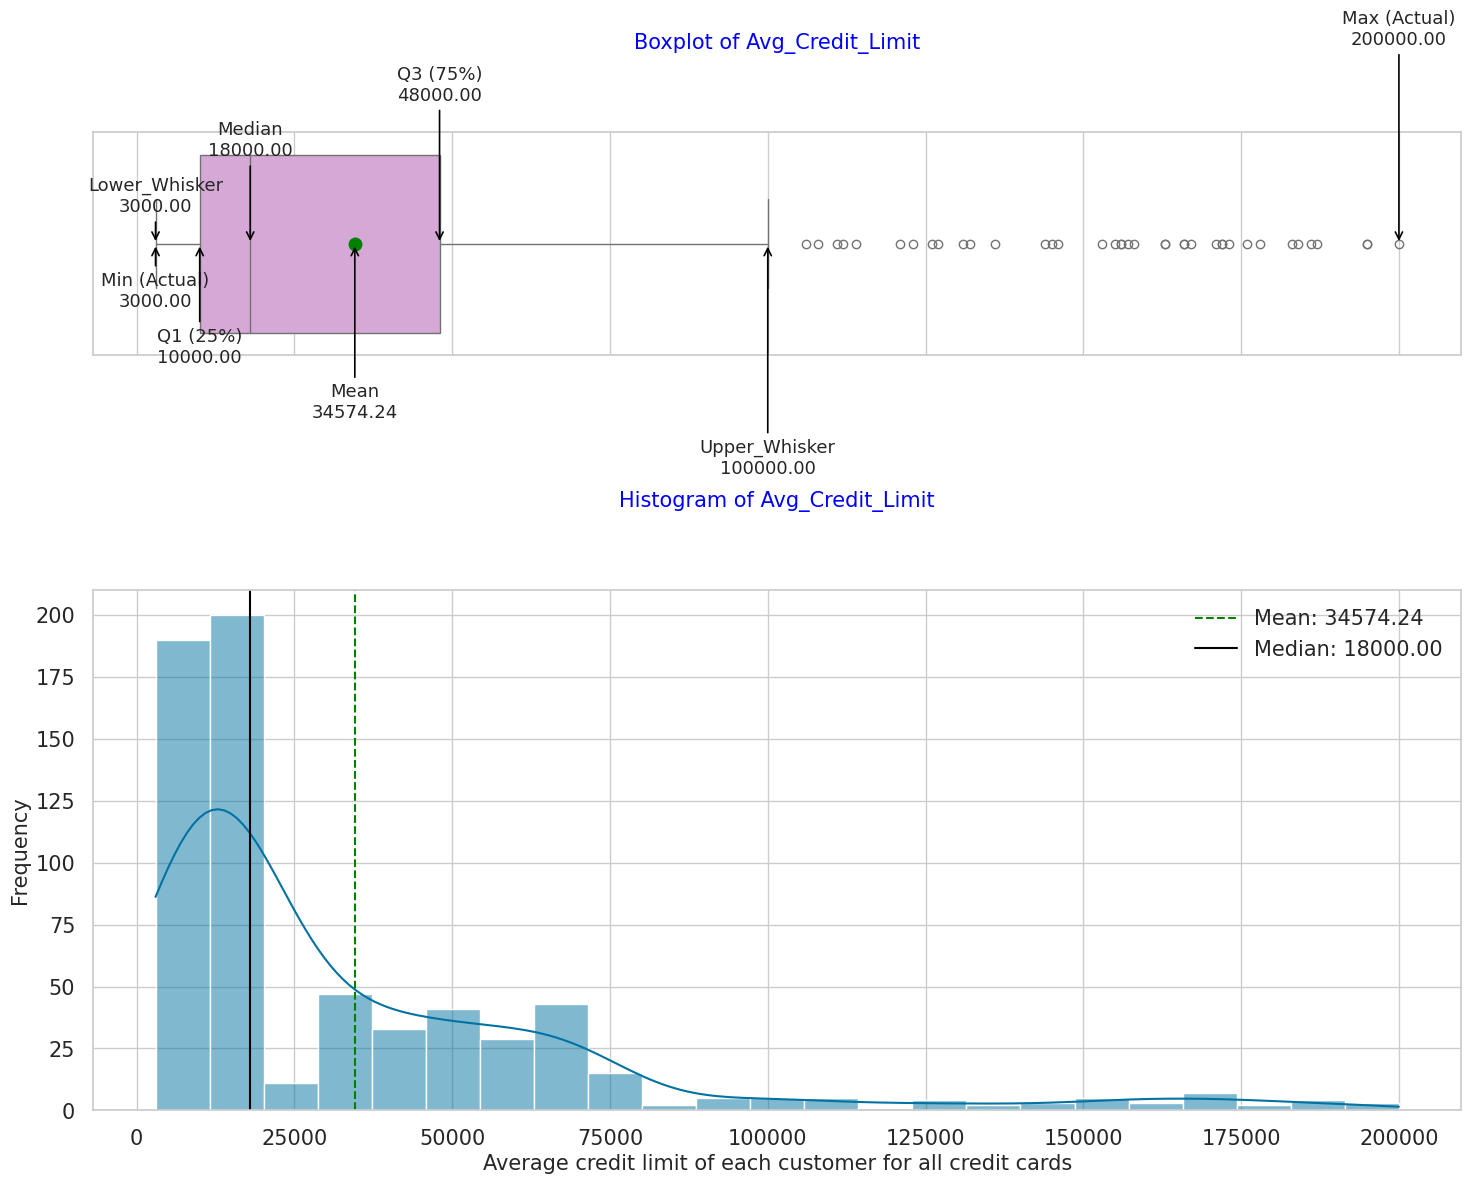

In [ ]:
histogram_boxplot(data, 'Avg_Credit_Limit', x_axis_title='Average credit limit of each customer for all credit cards')

- Data is highly right skewed with mean at ~35K and median at ~18K.
- Values range from 3K to 2 Lacs, thus variability is very high.
- 75% customers have average credit limit equal to and below 50K.
- There are several outliers, especially in high range (We won't be treating them as they are genuine values).

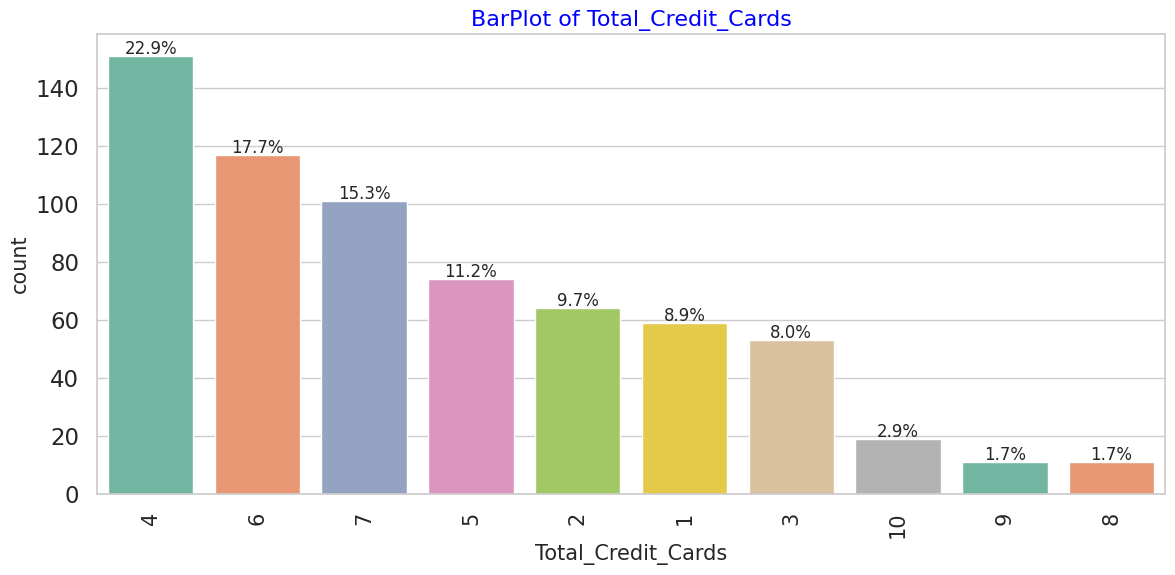

In [ ]:
# Get the order of categories by descending count
labeled_barplot(data, 'Total_Credit_Cards', perc=True)

- Majority people have 4 credit cards (23%), followed by 5-7 credit cards (44%), followed by 1-3 credit cards (27%) and trace for 8-10 credit cards (6%).

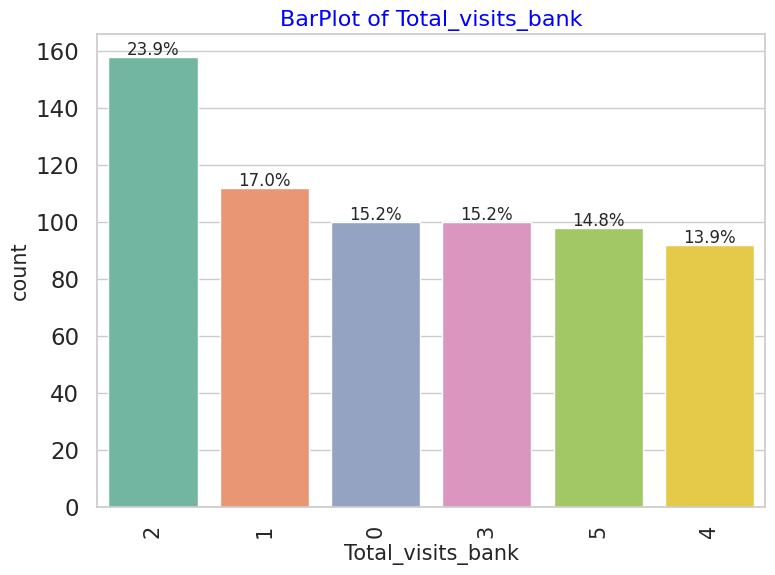

In [ ]:
labeled_barplot(data, 'Total_visits_bank', perc=True)

- Most customers visited the bank 2 times (approx. 24%) indicating that bi-annually visits may be the most common behavior.
- About 17% visited only once, and 15.2% didn't visit at all. This suggests a sizable group is either new, inactive, or prefers digital banking.
- Around 15.2% visited 3 times, and 14.8% visited 5 times. Customers visiting 4 times are the least common (13.9%). This shows that frequent physical branch users are still a consistent, though not dominant segment.
- Digital engagement opportunities: The 15%+ customers with 0 or 1 visit could be nudged towards digital services or targeted for re-engagement campaigns.
- High-engagement customers (3–5 visits) might be better served with loyalty programs, priority services, or personal banking offers.
- Consider optimizing branch operations around peak footfall frequencies (like 2 visits/year segments).

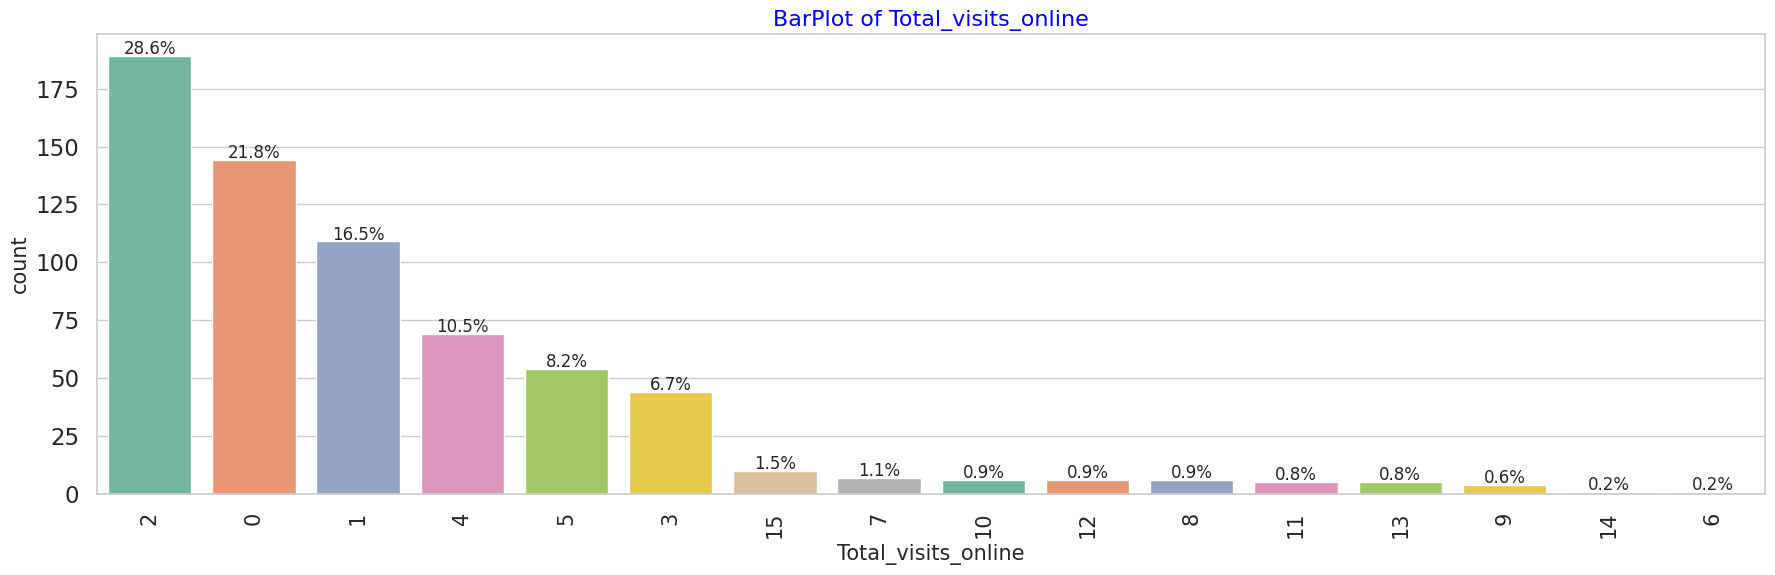

In [ ]:
labeled_barplot(data, 'Total_visits_online', perc=True)

- Total online visits are max at 0-2 per year (67% customers), showing less digital orientation and might be the preference for physical banking. There is Digital Adoption Opportunity to focus on converting these users through digital onboarding, app training, and incentives.
- Almost 25% people have 3-5 online visits per year, indicating decent digital presence.
- Remaining traces (around 8% people) visit online more than 5 times annually. These are the tech-savvy people who might need better digital services, online offers, etc.

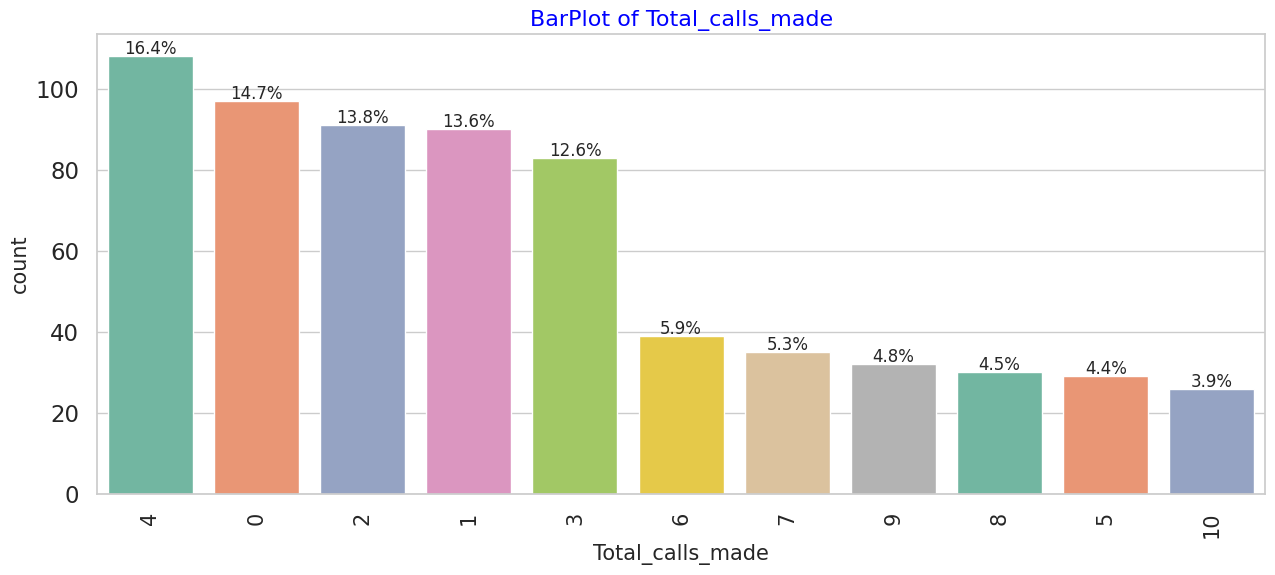

In [ ]:
labeled_barplot(data, 'Total_calls_made', perc=True)

- Majority customers lie in 0-4 calls/year (71%), indicating either low or no engagement. Company should see if the issues are less and get resolved faster or the customer base is not having faith in the services
- 29% people who make 5 or more calls annually, especially 13% people who make 8-10 calls need attention. They might be facing repetitive issues and need attention to retain them.

##Bivariate Analysis

###Pairplot of all numerical columns

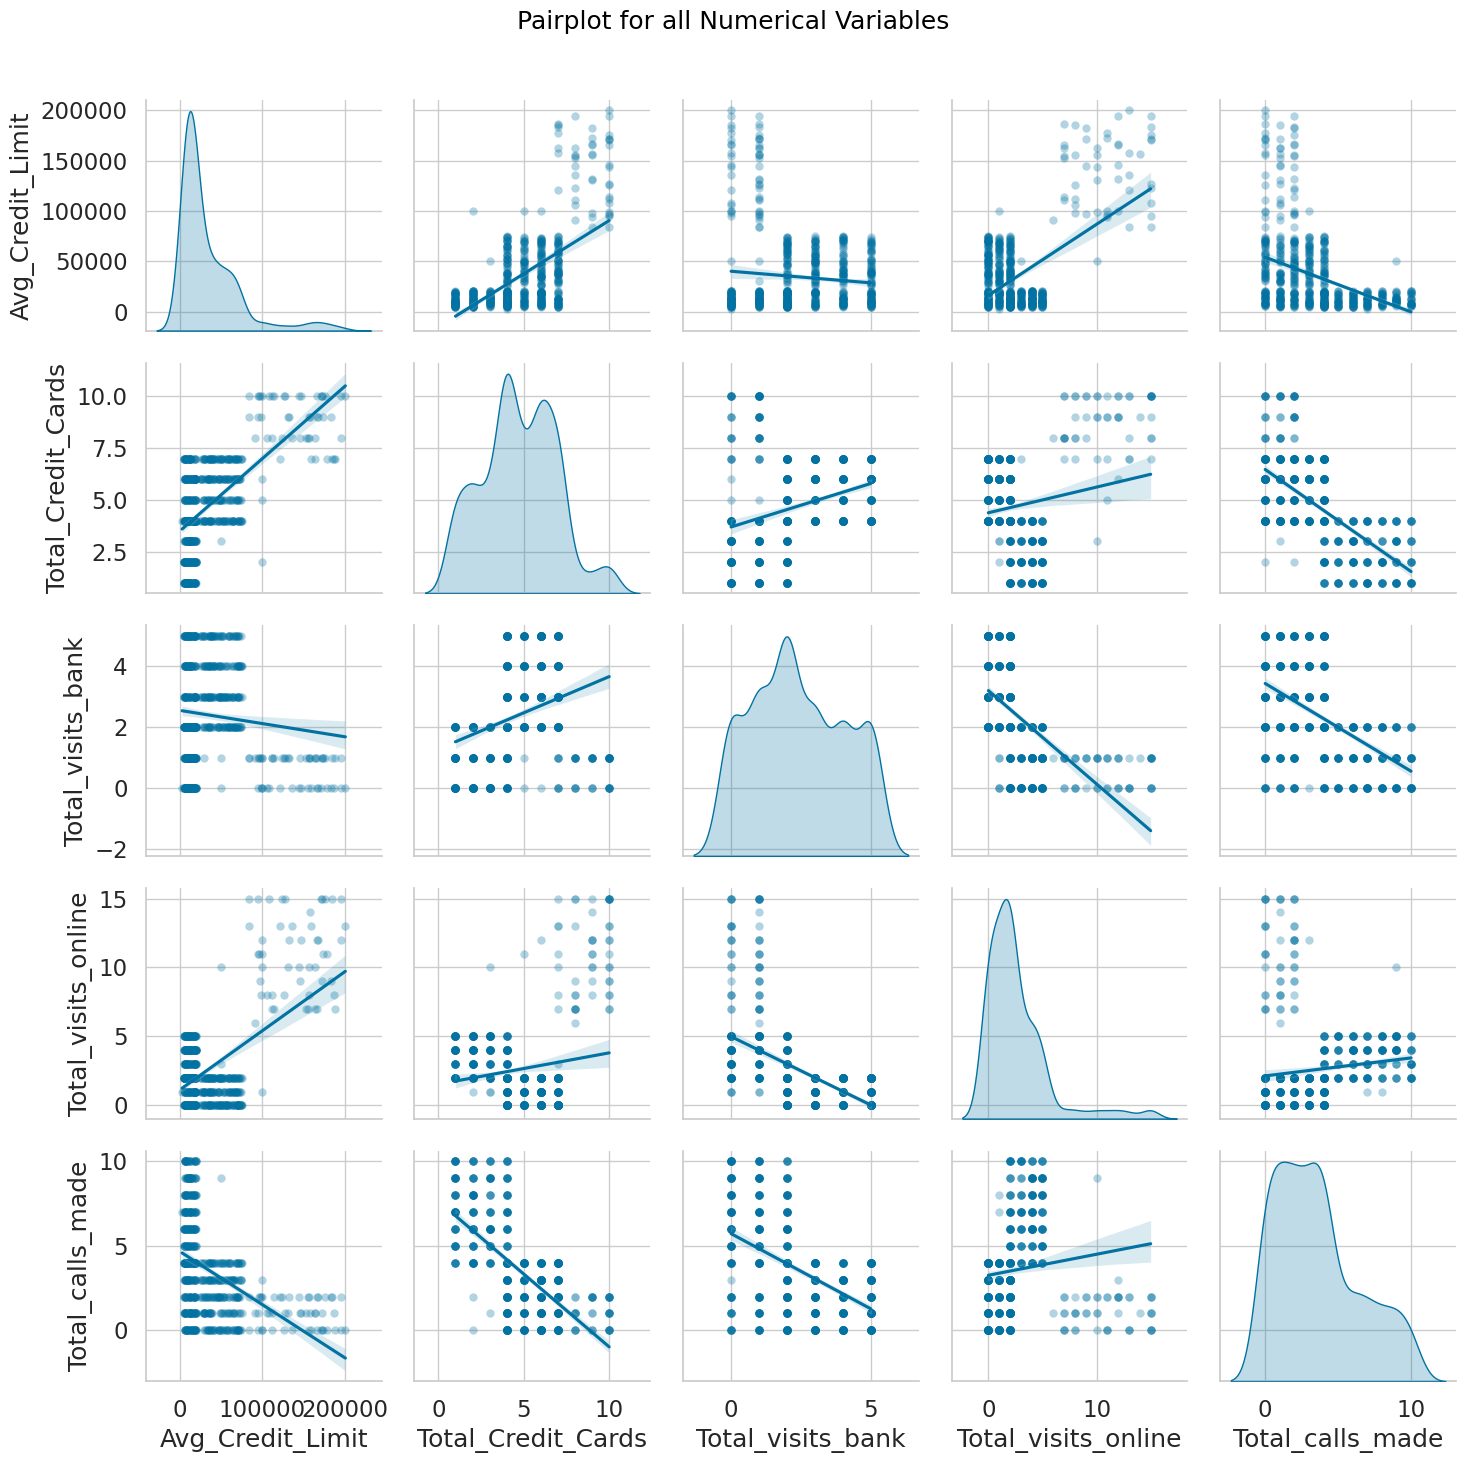

In [ ]:
sns.set_context("notebook", font_scale=1.5) # Set font size for pairplot
sns.set_style("whitegrid") #Setting Good Style
g = sns.pairplot(data,kind='reg',diag_kind="kde", height=3,
             plot_kws={"scatter_kws": {"alpha": 0.3}},
             palette="coolwarm") # Generating Pairplot with Regression Line, KDE Line, Good Enough Transparency and Palette
# Add a title to the entire figure
g.fig.suptitle('Pairplot for all Numerical Variables', fontsize=18, color='black')

# Adjust spacing so the title doesn't overlap
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.92)
plt.show()

##Correlation Heatmap of all numerical columns

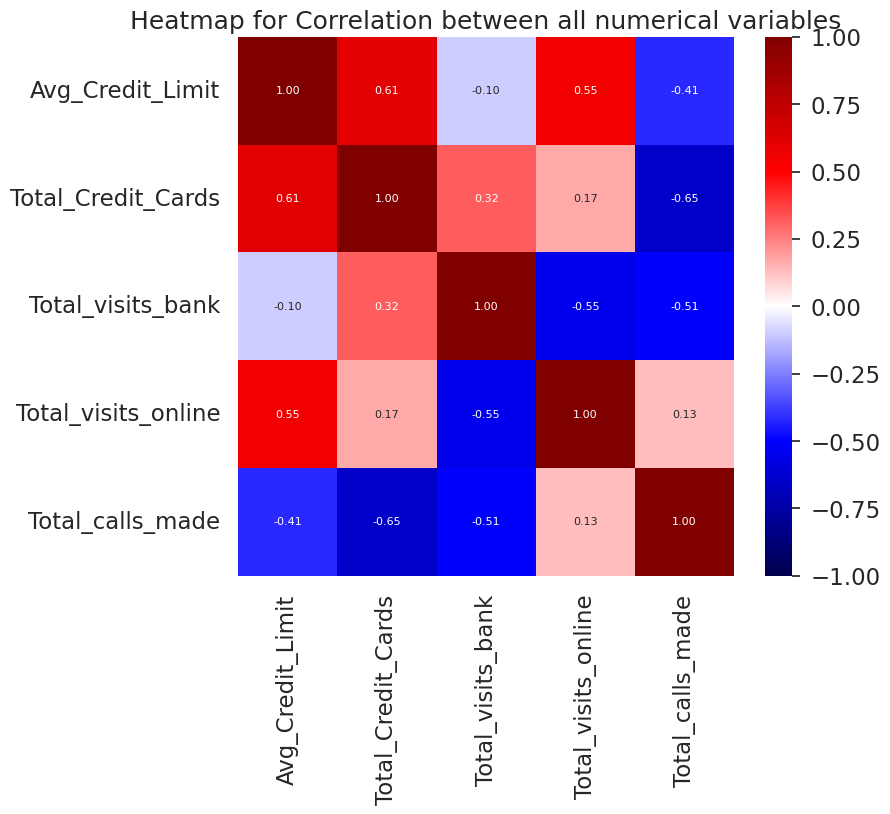

In [ ]:
# Generating Heatmap to study correlation
plt.figure(figsize=(8, 7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="seismic", annot_kws={"size": 8})
plt.title('Heatmap for Correlation between all numerical variables')
plt.show()

- Customers with More credit cards have higher Avg Credit Limit, visit bank more and have less phone calls.
- Customers with higher Avg Credit Limit tend to visit online more and make less phone calls, thus digitalisation is preferred here.
- Customers who visit bank more, visit online less and make less use of phone banking. These are traditional and less digitally aligned customers that prefer in person banking.
- Customers who make more phone calls, have less average credit limit, credit cards and make less bank visits. This is mostly dissatisfied customer base that needs to be tapped by resolving their issues, digital training , etc.

# Data Pre-Processing

* Insignificant columns Sl_No and Customer Key have already been dropped as they add no value to the analysis and so to model/cluster building.
* We have already checked for duplicate values, missing values and we have not witnessed any of them.
Also, we have not observed any anamoly, irregularity till yet.
So, the data is clean to proceed furhter in the analysis.


##Outlier Detection

We will check and treat (if necessary) outliers.

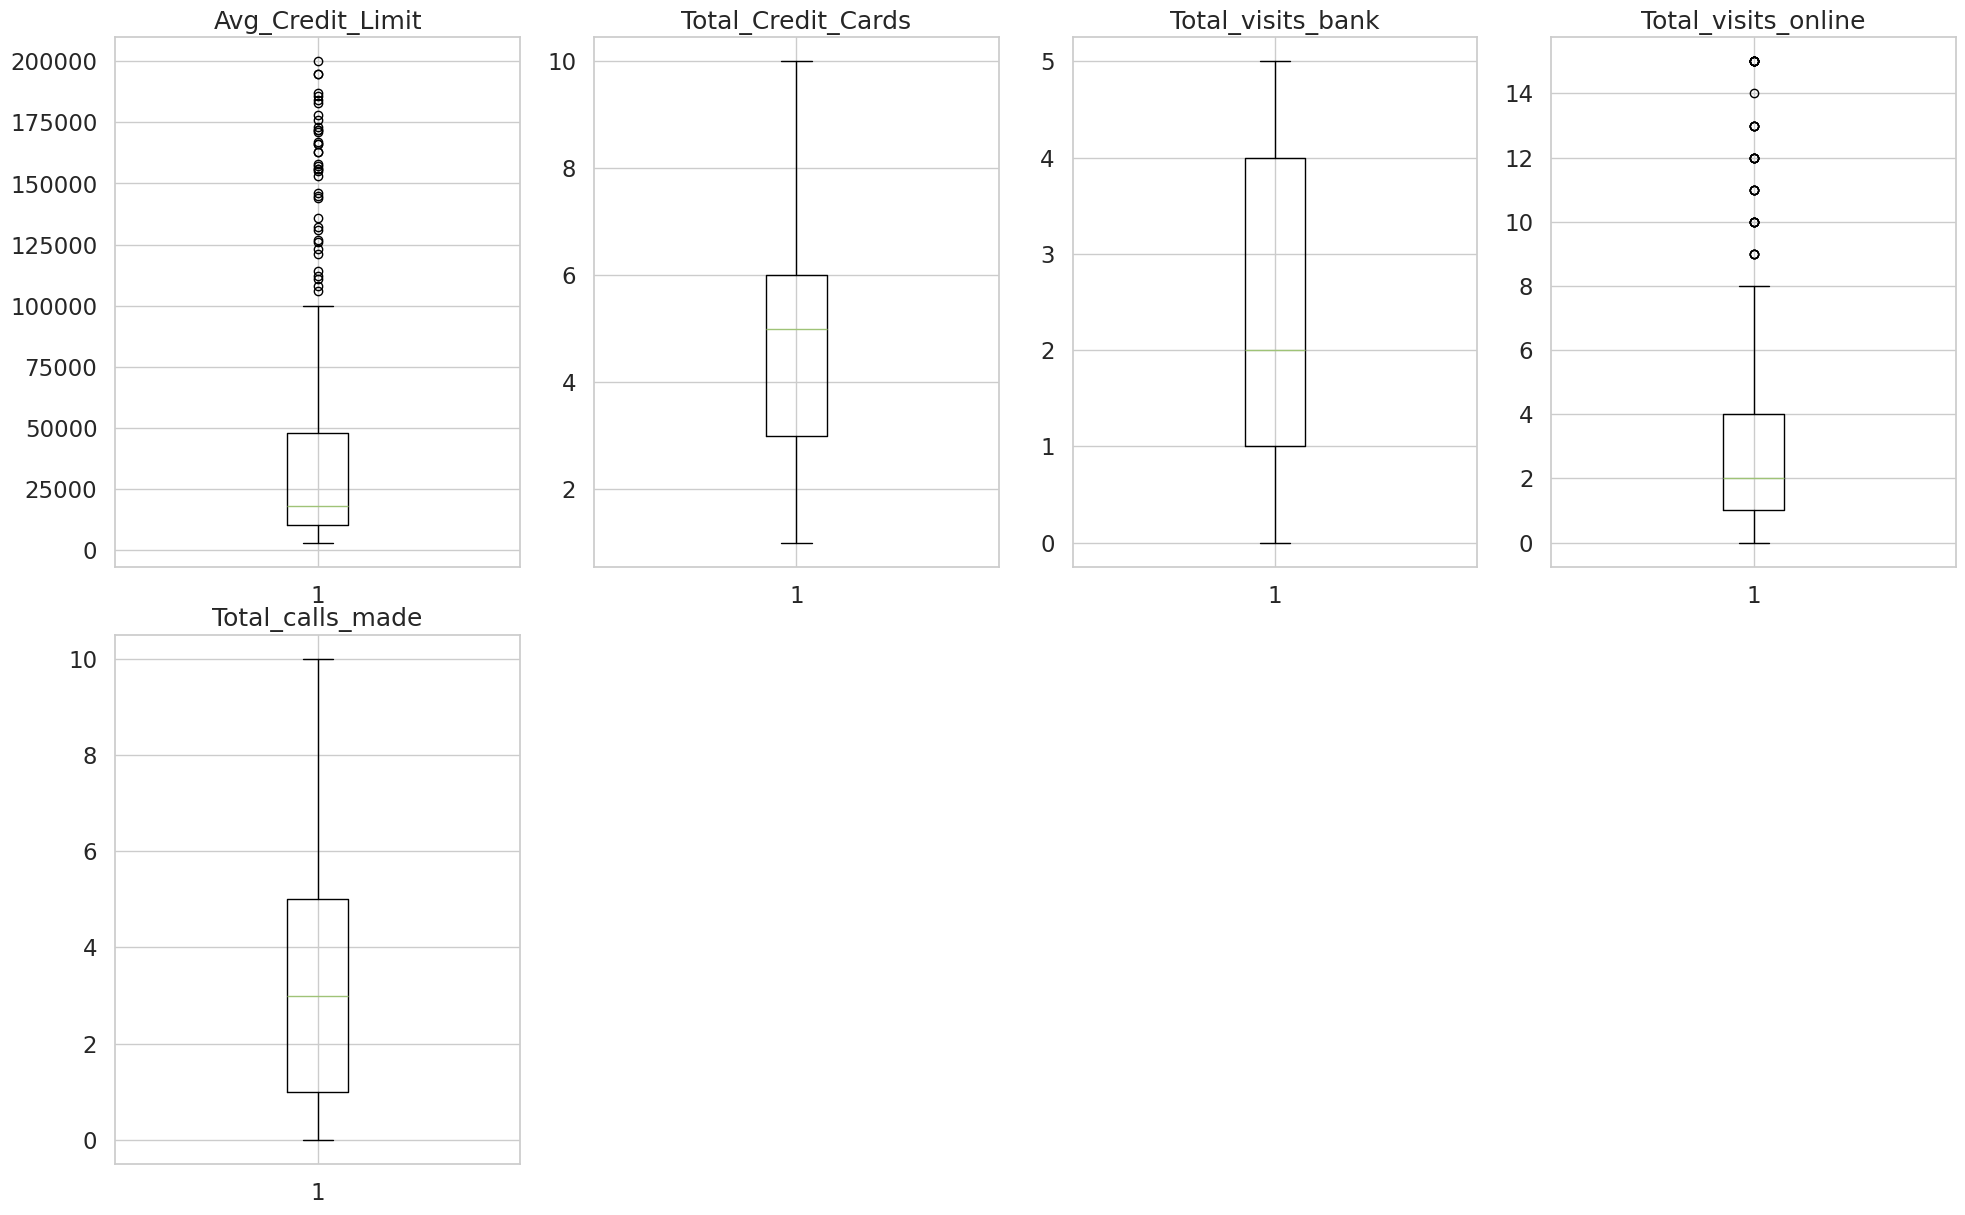

In [ ]:
# outlier detection using boxplot

numerical_col = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 30))
for i, variable in enumerate(numerical_col):
  plt.subplot(5, 4, i+1)
  plt.boxplot(data[variable], whis=1.5)
  plt.tight_layout()
  plt.title(variable)
plt.show()

- There are several outliers present in Avg_Credit_Limit and Total_visits_online, especially in higher ranges.
- **Outliers are NOT being treated as these are real values and represent real world data.**

##Data Scaling

**Let's scale the data before we proceed further with clustering because clustering algorithms, particularly distance-based ones like K-Means and hierarchical clustering, are sensitive to the scale of the features. Features with larger values can dominate the distance calculations, leading to biased results.**

**StandardScaler applies Z-score standardization, transforming each feature to have a mean of 0 and a standard deviation of 1. This brings all features to a similar scale without distorting the differences in the ranges of values, which is important for accurately calculating distances between data points and thus forming meaningful clusters based on all features equally.**


In [ ]:
scaler = StandardScaler()

# columns to be used for clustering are
col_for_clustering = [c for c in data.columns]
print(col_for_clustering)

['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']


In [ ]:
df_scaled = data[col_for_clustering].copy()
df_scaled.iloc[:, :] = scaler.fit_transform(df_scaled.iloc[:, :])
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739


In [ ]:
# creating dataframe copies for k-means and hierarchiacal clustering
km_df = data.copy()
hc_df = data.copy()

# Model Building - K-means Clustering

## Checking Elbow Plot

Number of Clusters: 2 	Average Distortion: 1.7178787250175898
Number of Clusters: 3 	Average Distortion: 1.1466276549150365
Number of Clusters: 4 	Average Distortion: 1.0902973540817666
Number of Clusters: 5 	Average Distortion: 0.9906853650098948
Number of Clusters: 6 	Average Distortion: 0.9515009282361341
Number of Clusters: 7 	Average Distortion: 0.9094119827472316
Number of Clusters: 8 	Average Distortion: 0.9191292344244387
Number of Clusters: 9 	Average Distortion: 0.8990131857179275
Number of Clusters: 10 	Average Distortion: 0.8723089051392604


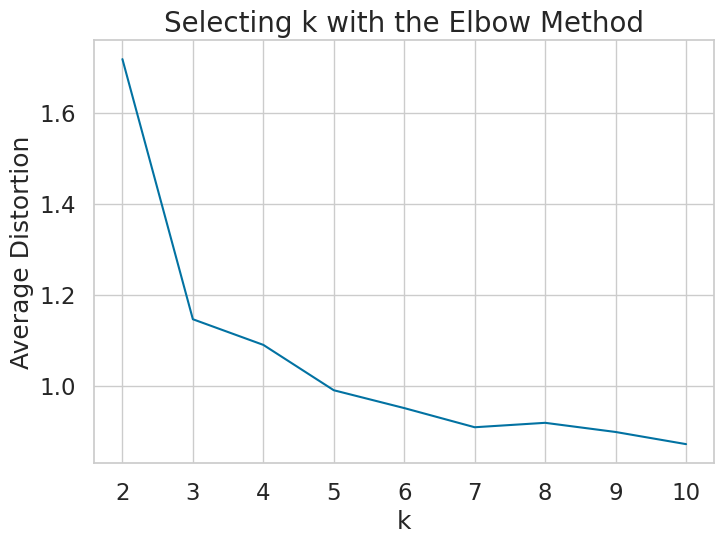

In [ ]:
clusters = range(2, 11)
meanDistortions = []

for k in clusters:
  model = KMeans(n_clusters=k, random_state=1)
  model.fit(df_scaled)
  prediction = model.predict(df_scaled)
  distortion = (
      sum(np.min(cdist(df_scaled, model.cluster_centers_, "euclidean"), axis=1))
      / df_scaled.shape[0]
  )

  meanDistortions.append(distortion)

  print ("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

Let's do further analysis to determine the optimal value of k.

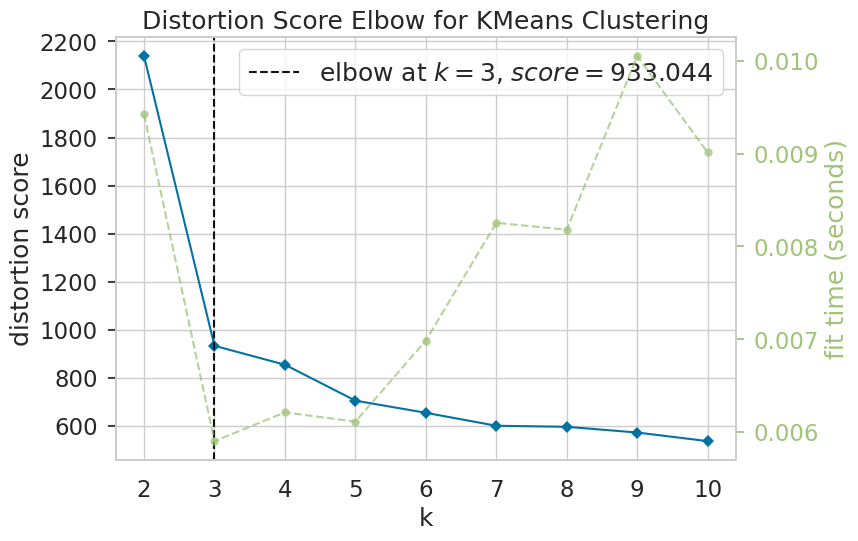

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=True)
visualizer.fit(df_scaled) # fit the scaled data to the visualizer
visualizer.show() # finalize and render figure

* From the Elbow Plot (Distortion Score), it seems 3 is good value for k.

##Checking Silhouette Score

Let's check the silhouette scores.


For n_clusters = 2, the silhouette score is 0.5703183487340514
For n_clusters = 3, the silhouette score is 0.5157182558881063
For n_clusters = 4, the silhouette score is 0.3744071798973986
For n_clusters = 5, the silhouette score is 0.27167502160723267
For n_clusters = 6, the silhouette score is 0.24804756291576194
For n_clusters = 7, the silhouette score is 0.24791254258020035
For n_clusters = 8, the silhouette score is 0.22570382558070443
For n_clusters = 9, the silhouette score is 0.19931783829027247
For n_clusters = 10, the silhouette score is 0.20939001908412339


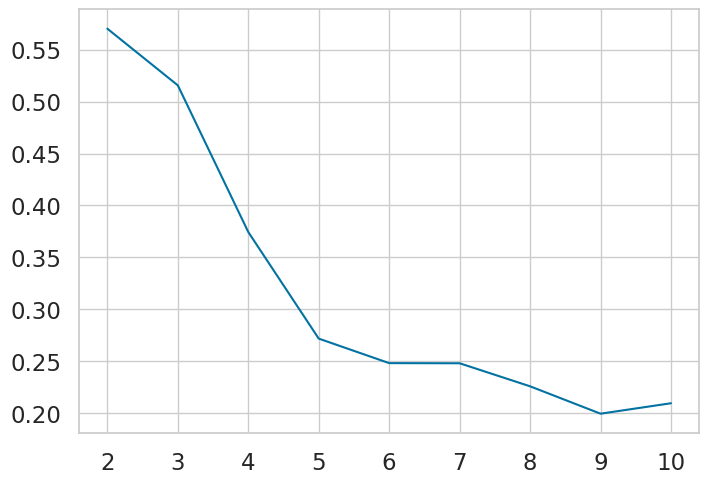

In [ ]:
sil_score = []
cluster_list = range(2, 11)

for n_clusters in cluster_list:
  clusterer = KMeans(n_clusters=n_clusters, random_state=1)
  preds = clusterer.fit_predict(df_scaled)
  score = silhouette_score(df_scaled, preds)
  sil_score.append(score)
  print(("For n_clusters = {}, the silhouette score is {}").format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

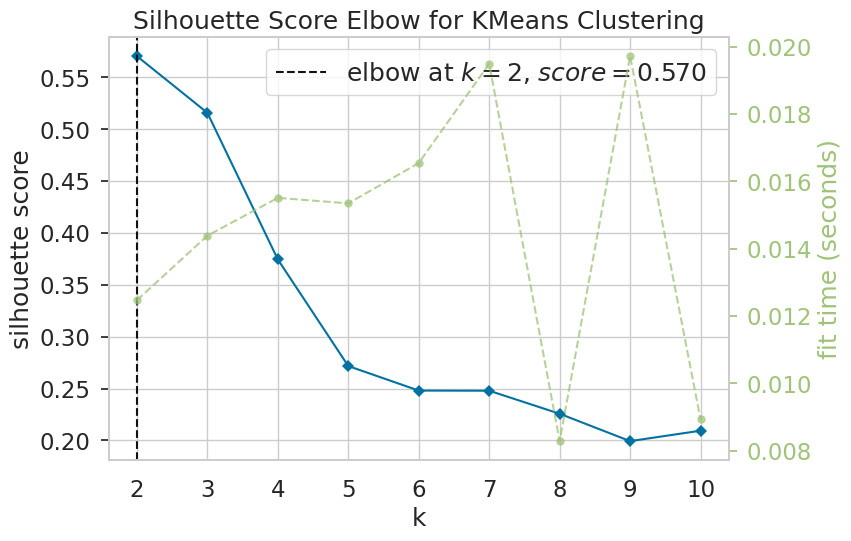

CPU times: user 870 ms, sys: 4.72 ms, total: 875 ms
Wall time: 1.09 s


<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
%%time
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette",timings=True)
visualizer.fit(df_scaled) # fit the scaled data to the visualizer
visualizer.show() # finalize and render the figure

* From the Silhouette Score, it seems that 2 is the good value for k.

###Silhouette Plot

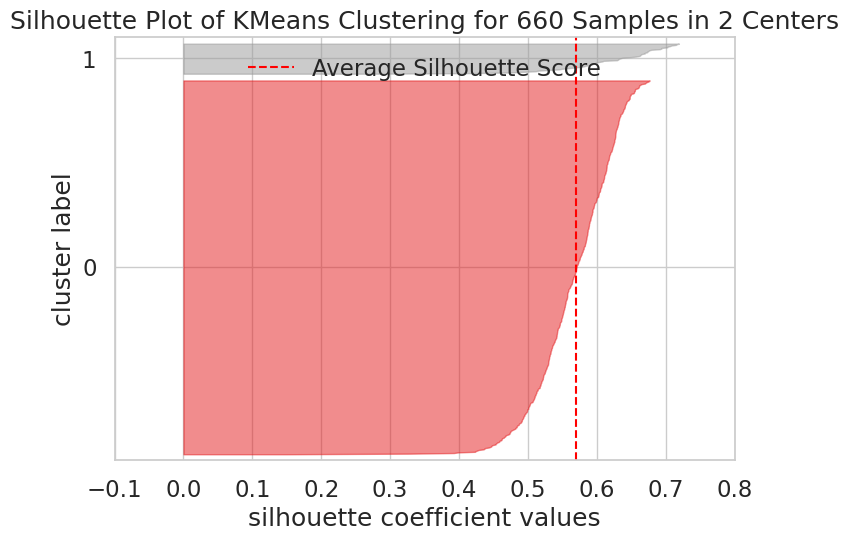

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(n_clusters=2, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

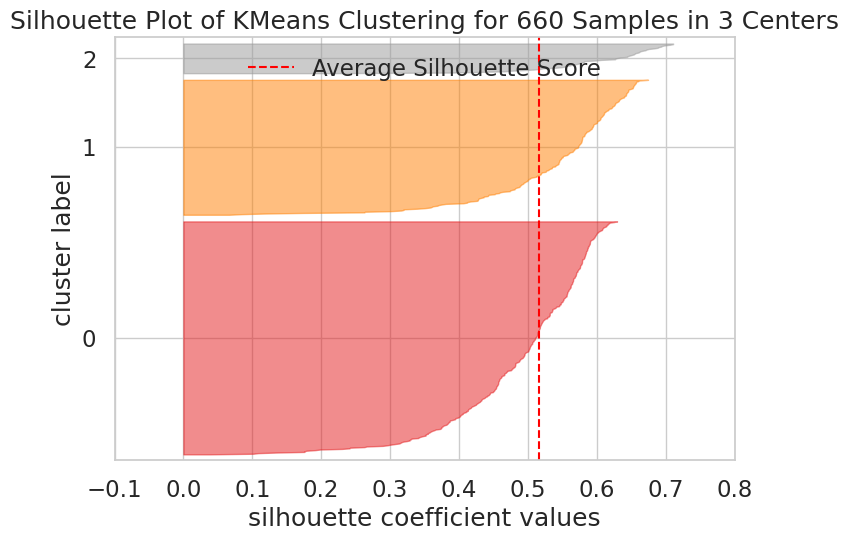

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(n_clusters=3, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

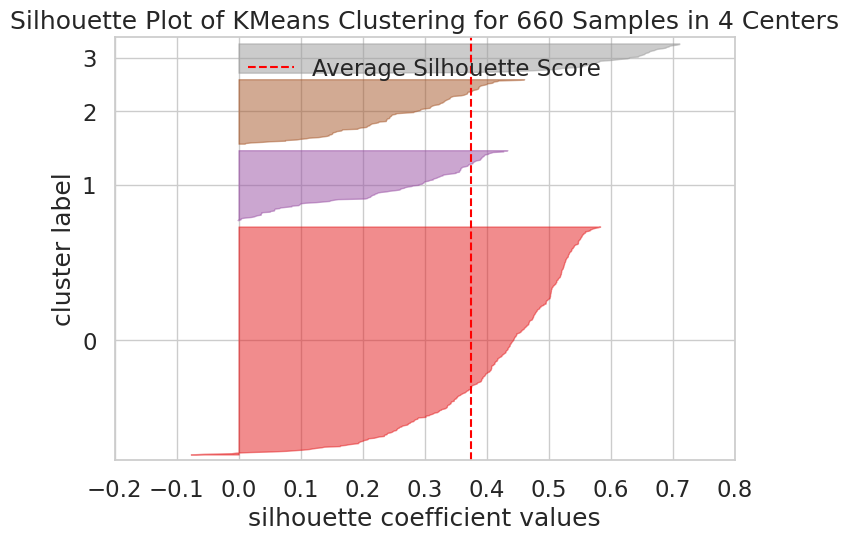

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(n_clusters=4, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

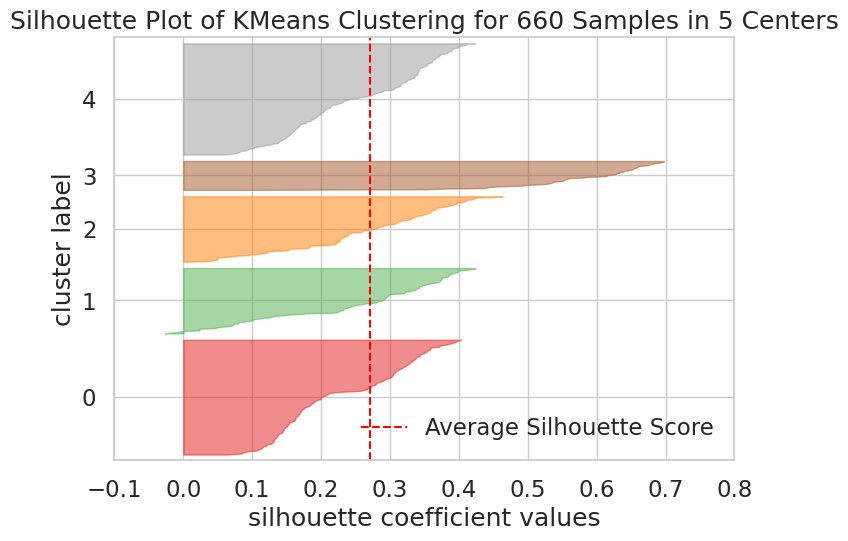

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(n_clusters=5, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

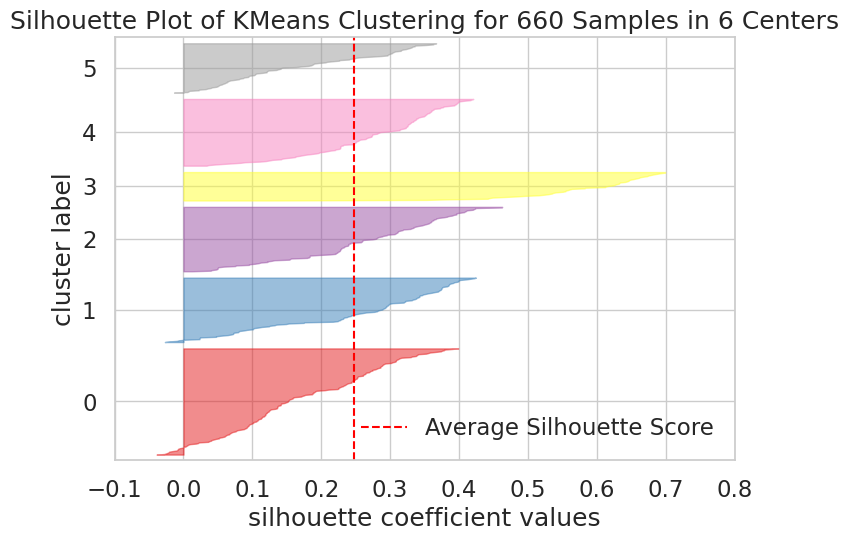

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal number of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(n_clusters=6, random_state=1))
visualizer.fit(df_scaled)
visualizer.show()

**We will proceed with k=3 (optimal number of clusters) because**


*   **The Average Silhouette Score is around 0.515, which is good (above 0.5).**
* **Though k=2 have little bit better Average Silhouette Score 0.570 than that of k=3, but the elbow in the Elbow Plot (Distortion Score) for k=3 is reasonable than that for k=2.**
* **Clusters are relatively well-separated, with NO negative Silhouette scores and thus no misclassified points.**



## Creating Final Model

In [ ]:
%%time
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(df_scaled)

CPU times: user 6.99 ms, sys: 0 ns, total: 6.99 ms
Wall time: 10.3 ms


KMeans(n_clusters=3, random_state=1)

In [ ]:
# adding kmeans cluster labels to the original dataframe
data["K_means_segments"] = kmeans.labels_

##Cluster Profiling


In [ ]:
temp_df = df.assign(K_means_segments=kmeans.labels_)

# get unique 'Customer Key's for each cluster
cluster_customers = temp_df.groupby('K_means_segments')['Customer Key'].unique()

# convert to dictionary for easier access or inspection
cluster_customer_dict = cluster_customers.to_dict()

# to print each cluster's customers:
for cluster, customers in cluster_customer_dict.items():
  print(f"Customers in Cluster {cluster}:")
  print(customers)
  print("-"*100)

Customers in Cluster 0:
[87073 17341 40496 54838 35254 46635 97825 83125 35483 15129 83290 56486
 31903 45909 14263 46813 81878 35549 85799 39122 81531 69965 18595 44398
 32352 40898 27101 33457 45088 23302 27408 65372 21531 56843 17165 89328
 20072 71402 47496 24808 17036 67193 34423 97109 55382 51811 53936 66504
 53207 18514 51319 36340 36934 95925 49771 22919 21233 74544 52025 45652
 73952 49418 77026 49331 75775 54906 94666 11698 34677 95610 41380 38033
 85337 38994 67911 92956 77641 57565 53814 30712 19785 31384 16374 50878
 78002 83459 91987 51552 24998 45673 11596 87485 28414 81863 33240 11466
 23881 44645 49844 92782 22824 26767 26678 50412 17933 34495 47437 22610
 41159 64672 62483 85614 96548 19137 69028 70779 38244 67046 64897 46223
 36628 17565 77381 11799 81940 66706 87838 94437 33790 44402 29886 66804
 47866 61996 15318 89635 71681 71862 96186 22348 36243 88807 82376 98126
 80347 17649 62807 92522 57459 44579 45476 61994 11398 24702 27824 45878
 72431 19215 23409 16418 85

In [ ]:
cluster_profile = data.groupby("K_means_segments").mean(numeric_only=True)
cluster_profile["count_in_each_segment"] = (
    data.groupby("K_means_segments").size().values
)

# let's display clusters' profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
K_means_segments,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


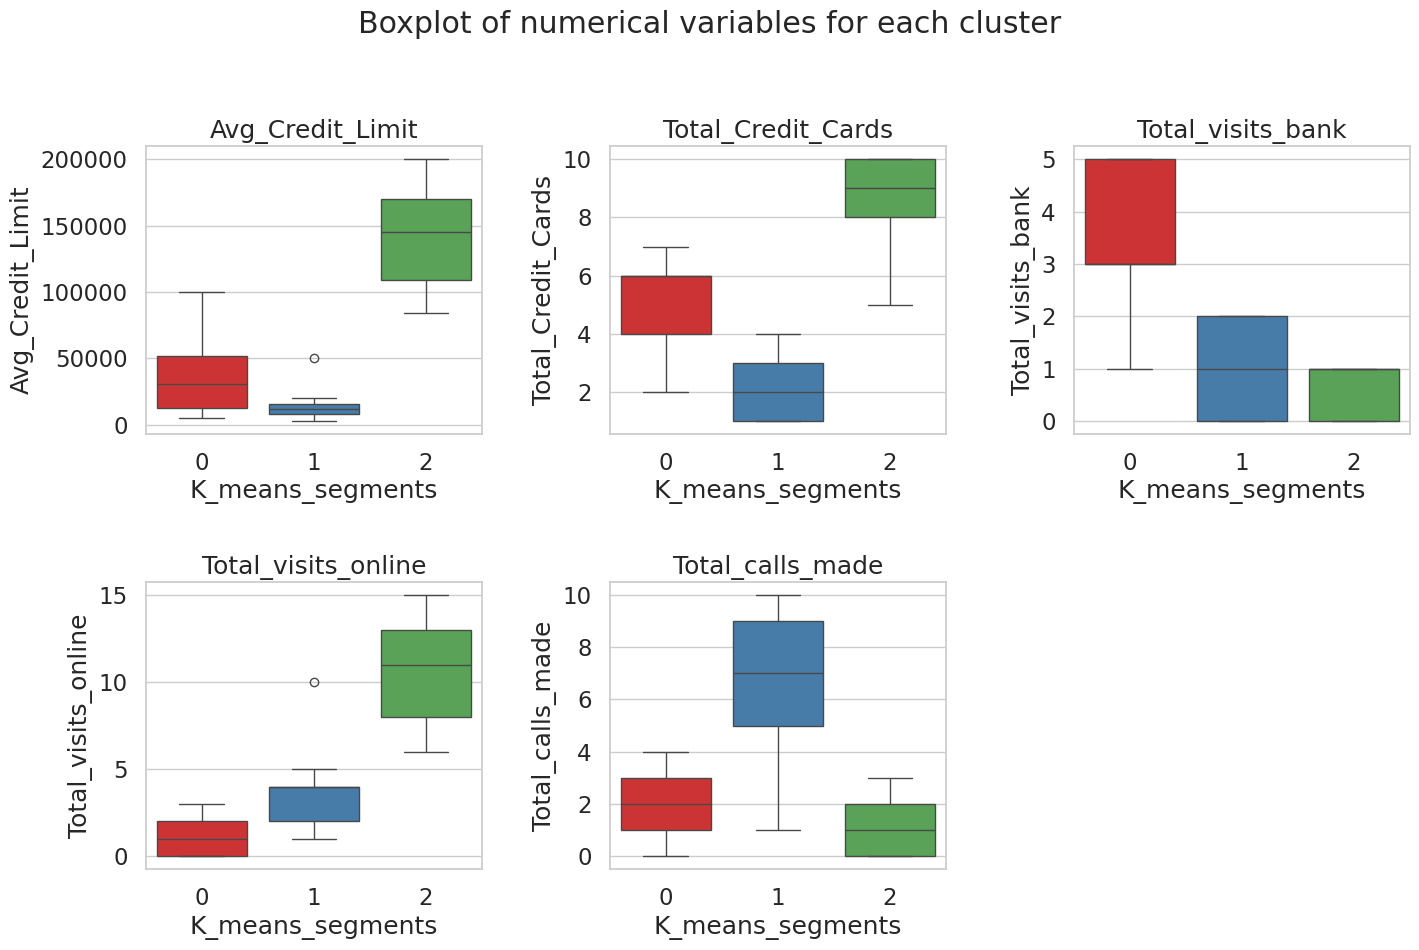

In [ ]:
plt.figure(figsize=(15,10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numerical_col):
  plt.subplot(2, 3, i+1)
  sns.boxplot(data=data, x="K_means_segments", y=variable, hue="K_means_segments", palette='Set1', legend=False)
  plt.tight_layout()
  plt.title(variable)

plt.tight_layout(pad=2.0)

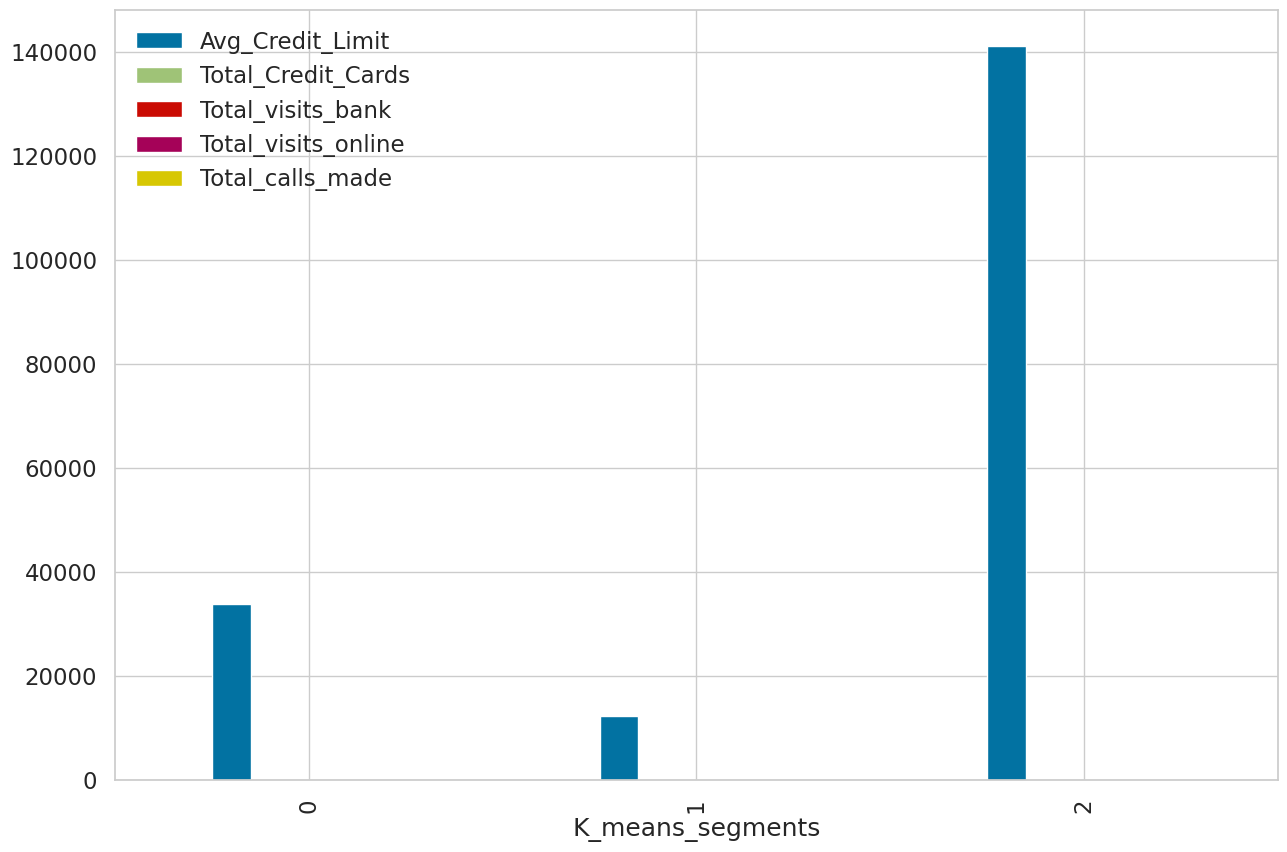

In [ ]:
data.groupby("K_means_segments").mean(numeric_only=True).plot.bar(figsize=(15, 10))
plt.show()

**Since values have huge scale differences, in order to visualize them in a single graph, we must normalize them before plotting.**

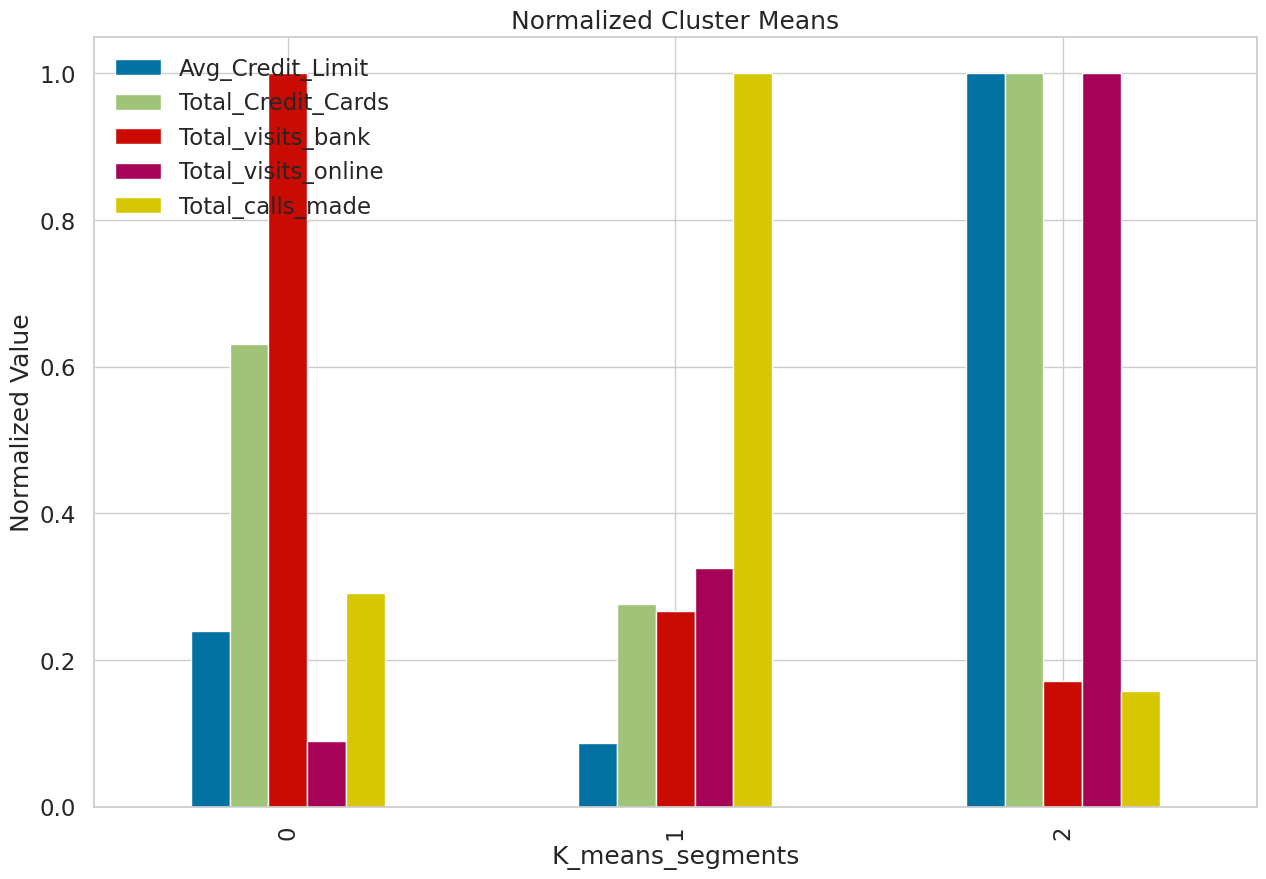

In [ ]:
grouped_data = data.groupby("K_means_segments").mean(numeric_only=True)
normalized = grouped_data / grouped_data.max() # scale to [0, 1]

normalized.plot.bar(figsize=(15, 10))
plt.title("Normalized Cluster Means")
plt.ylabel("Normalized Value")
plt.show()


###Insights

#### Cluster 0:
- Highest Total_visits_bank
- High Total_Credit_Cards
- Low Total_visits_online
- Likely traditional customers who frequently visit banks physically and have multiple credit cards due to years of banking relationship , these are possibly old customers with traditional banking.
#### Cluster 1:
- High Total_calls_made
- Low Avg_Credit_Limit
- Moderate values for other features
- Possibly represents high-touch, lower credit customers who rely more on phone calls than digital banking.
####Cluster 2:
- Highest Avg_Credit_Limit, Total_Credit_Cards, and Total_visits_online
- Low Total_visits_bank and Total_calls_made  
 **Probably digitally-savvy premium customers with high credit limits and less reliance on traditional or phone channels. Bank should focus more on these with premium offering and features as they are high profit and tech savvy customers who are crucial to maintain and need more focus , otherwise they may migrate to competitors if not satisfied by the services.**

#Model Building - Hierarchical Clustering

##Computing Cophenetic Correlation

In [ ]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

#list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
  for lm in linkage_methods:
    Z = linkage(df_scaled, metric=dm, method=lm)
    c, coph_dists = cophenet(Z, pdist(df_scaled))
    print(
        "Cophenetic correlation for {} distance and {} linkage is {}.".format(
            dm.capitalize(), lm, c
        )
    )
    if high_cophenet_corr < c:
      high_cophenet_corr = c
      high_dm_lm[0] = dm
      high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.7391220243806552.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8599730607972423.
Cophenetic correlation for Euclidean distance and average linkage is 0.8977080867389372.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8861746814895477.
Cophenetic correlation for Chebyshev distance and single linkage is 0.7382354769296767.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8533474836336782.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8974159511838106.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8913624010768603.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.7058064784553605.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6663534463875359.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8326994115042136.
Cophenetic co

In [ ]:
# printing the combination of distance metric and linkage method the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389372, which is obtained with Euclidean distance and average linkage.


**Let's explore different linkage methods with Euclidean distance only.**

In [ ]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
  Z = linkage(df_scaled, metric="euclidean", method=lm)
  c, coph_dists = cophenet(Z, pdist(df_scaled))
  print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
  if high_cophenet_corr < c:
    high_cophenet_corr = c
    high_dm_lm[0] = "euclidean"
    high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.7391220243806552.
Cophenetic correlation for complete linkage is 0.8599730607972423.
Cophenetic correlation for average linkage is 0.8977080867389372.
Cophenetic correlation for centroid linkage is 0.8939385846326323.
Cophenetic correlation for ward linkage is 0.7415156284827493.
Cophenetic correlation for weighted linkage is 0.8861746814895477.


In [ ]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389372, which is obtained with average linkage.


**We see that cophenetic correlation is maximum with Euclidean distance and average linkage.**

##Checking Dendrograms

Let's see the dendrograms for the different linkage methods

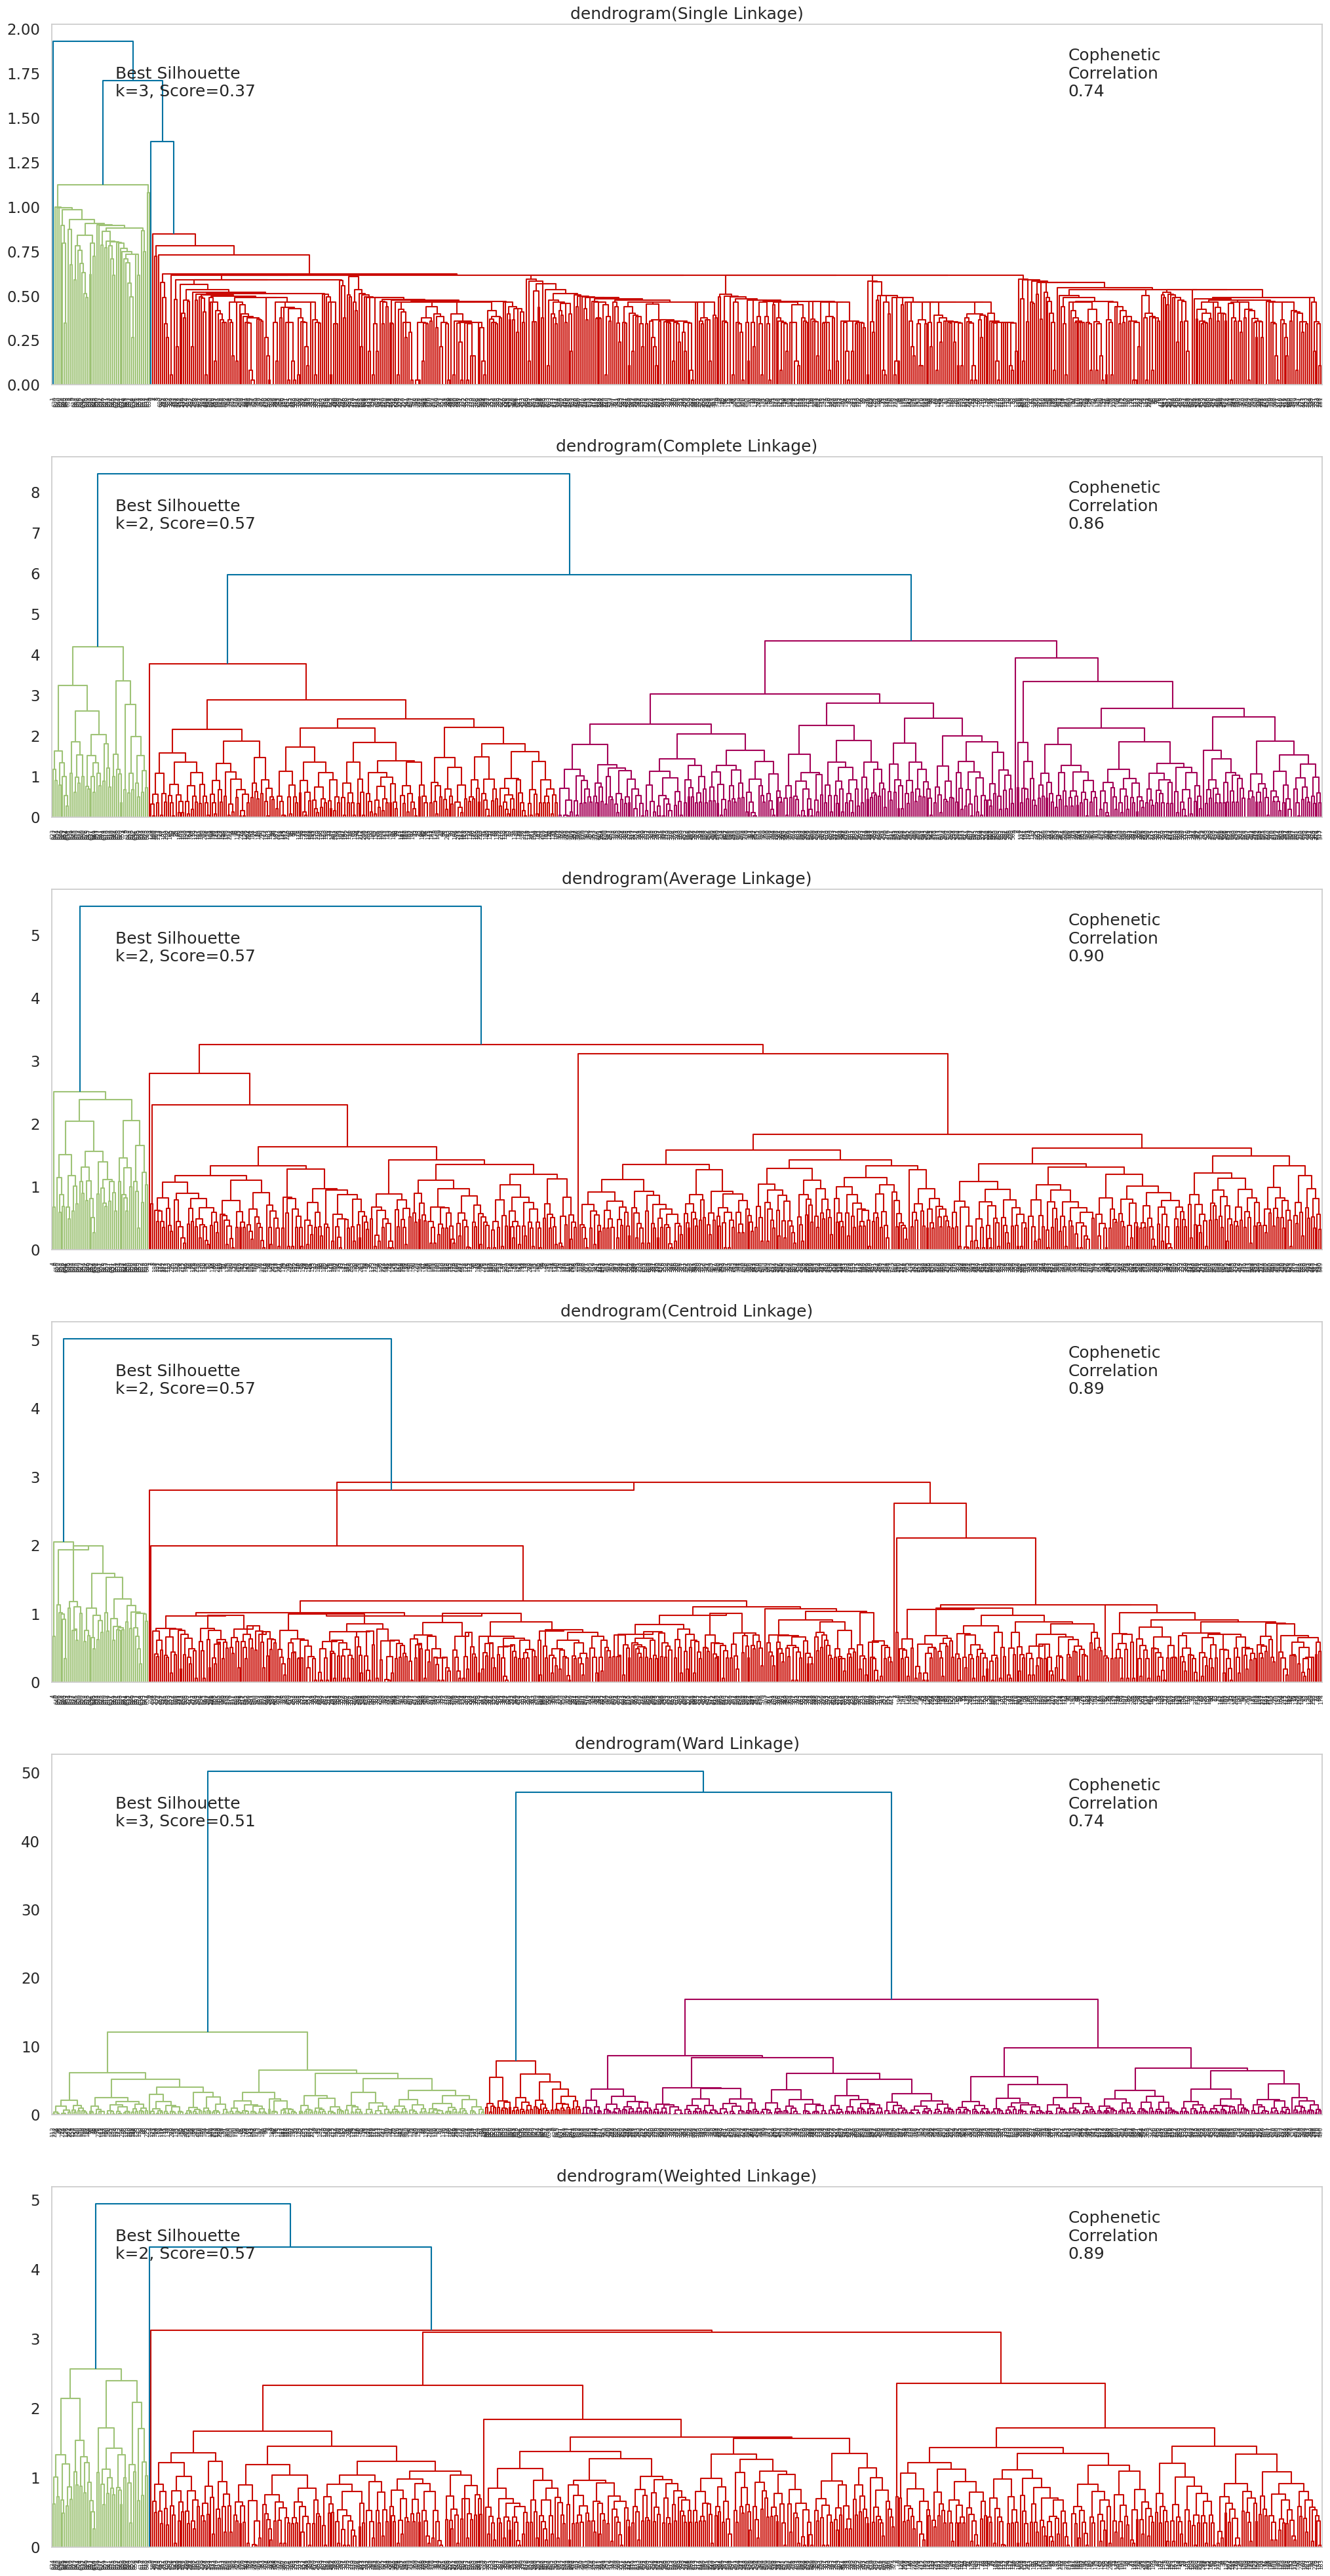

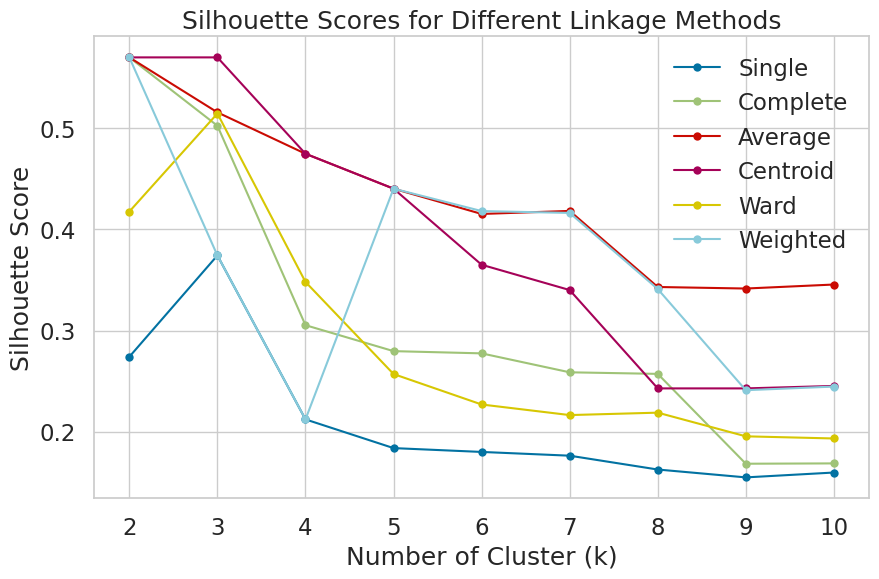


Silhouette Score Summary:
Single Linkage: Best k = 3, Silhouette Score = 0.374
Complete Linkage: Best k = 2, Silhouette Score = 0.570
Average Linkage: Best k = 2, Silhouette Score = 0.570
Centroid Linkage: Best k = 2, Silhouette Score = 0.570
Ward Linkage: Best k = 3, Silhouette Score = 0.515
Weighted Linkage: Best k = 2, Silhouette Score = 0.570
CPU times: user 25.3 s, sys: 212 ms, total: 25.5 s
Wall time: 31.4 s


In [ ]:
%%time

# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# store per-method silhouette scores for plotting
silhouette_all_methods = {} # {method: [scores_by_k]}
best_silhouette_summary = []


# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(25, 50))

# we will enumerate through the list of linkage methods above
# for each linkage method, we will plot the dendrogram and calculate cophenetic correlation
for i, method in enumerate(linkage_methods):
  Z = linkage(df_scaled, metric="euclidean", method=method)

  dendrogram(Z, ax=axs[i], leaf_rotation=90,
             leaf_font_size=6,
             no_labels=False,
             color_threshold=None)
  axs[i].set_title(f"dendrogram({method.capitalize()} Linkage)")
  axs[i].grid(False)
  coph_corr, coph_dist = cophenet(Z, pdist(df_scaled))
  axs[i].annotate(
      f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
      (0.80, 0.80),
      xycoords="axes fraction"
  )
  # compute silhouette score for cluster counts from 2 to 10
  silhouette_scores = []
  best_score = -1
  best_k = None
  for k in range(2, 11):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    if score > best_score:
      best_score = score
      best_k = k

  # store for overall plot
  silhouette_all_methods[method] = silhouette_scores
  best_silhouette_summary.append([method, best_k, best_score])

  # annotate silhouette score on dendrogram
  axs[i].annotate(
      f"Best Silhouette\nk={best_k}, Score={best_score:0.2f}",
      (0.05, 0.80),
      xycoords="axes fraction"
  )

# plot all silhouette curves
plt.figure(figsize=(10, 6))
cluster_range = range(2, 11)

for method in linkage_methods:
  scores = silhouette_all_methods.get(method, [])
  if len(scores) == len(cluster_range):
    plt.plot(cluster_range, scores,
             marker="o", label=f"{method.capitalize()}")
  else:
    print(f"Skippoing {method} - no valid silhouette scores.")

plt.title("Silhouette Scores for Different Linkage Methods")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()


 # print final silhouette results
print("\nSilhouette Score Summary:")
for method, best_k, score in best_silhouette_summary:
 print(f"{method.capitalize()} Linkage: Best k = {best_k}, Silhouette Score = {score:0.3f}")

- **The cophenetic correlation is highest for average and centroid linkage methods.**
- **We will move ahead with average linkage.**
- To determine the optimal number of clusters from the dendrogram we apply the horizontal cut method:  


a. Draw a horizontal line across the dendrogram where the vertical distance (height) between clusters is largest before merges — this indicates well-separated clusters.  
b. Count the number of vertical lines intersected by your horizontal cut — that’s optimal number of clusters.  
c. The biggest vertical jump is near the top (height ~5.5), where the last two clusters are merged into one (blue line).  
d.The tallest vertical line is the one merging the 2 main groups, around height = 5.5.  
e. The second tallest jumps occur around height = 3.3.  
f. A horizontal cut at ~3.3 intersects 3 main vertical branches → suggesting 3 clusters.  
g. A little below that , around ~3.1, we get 4 clusters but there is a single customer being segmented out to a new cluster, which is of no use  



- Thus, 3 appears to be the appropriate number of clusters from the dendrogram for average linkage because it gives
1. A balance between granularity and cohesion.
2. 3 clusters that are well-separated before a major merge happens.
3. Cutting higher gives only 2 very broad clusters (too coarse).
4. Cutting lower gives 4–5 clusters, but they are increasingly similar, possibly over-segmenting the data.  

- **However, since Silhouette score is better at k = 2 , we will first try k=2 and see if it makes business sense**

##Creating Model using sklearn (k=2)

In [ ]:
HCmodel = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="average")
HCmodel.fit(df_scaled)

df["HC_Clusters"] = HCmodel.labels_

In [ ]:
df_scaled

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739
...,...,...,...,...,...
655,1.713589,2.443892,-0.860451,2.520519,-1.251537
656,1.314621,2.443892,-0.860451,3.543188,-0.553005
657,2.937092,1.520613,-0.860451,2.179629,-0.902271
658,3.655235,2.443892,-0.860451,4.224968,-1.251537


In [ ]:
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters
0,1,87073,100000,2,1,1,0,0
1,2,38414,50000,3,0,10,9,0
2,3,17341,50000,7,1,3,4,0
3,4,40496,30000,5,1,1,4,0
4,5,47437,100000,6,0,12,3,1
...,...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0,1
656,657,60732,84000,10,1,13,2,1
657,658,53834,145000,8,1,9,1,1
658,659,80655,172000,10,1,15,0,1


##Cluster Profiling

In [ ]:
cluster_profile = df.groupby("HC_Clusters").mean(numeric_only=True)
cluster_profile["count_in_each_segment"] = (
    df.groupby("HC_Clusters").size().values
)
# let's see the details of the customers in each cluster
for cl in df["HC_Clusters"].unique():
  print("In cluster {}, the following customers are present:".format(cl))
  print(df[df["HC_Clusters"] == cl] ["Customer Key"].unique())
  print()

In cluster 0, the following customers are present:
[87073 38414 17341 40496 58634 37376 82490 44770 52741 52326 92503 25084
 68517 55196 62617 96463 39137 14309 29794 87241 30507 61061 24001 68067
 65034 14854 81130 29112 13999 32550 82164 61517 28254 30888 46388 74126
 52142 37659 83132 20119 52363 50769 68502 99026 83326 62040 37252 74625
 51182 60301 96386 43886 78503 68419 32828 17937 71632 81566 29759 36929
 70248 91673 61355 60403 85868 76205 66524 69214 21976 35149 27120 18821
 33187 93482 90168 71881 59656 12026 99589 38970 57990 39447 79694 79403
 47296 37559 38165 49198 18007 59619 37016 91099 74704 25742 11937 52736
 88338 18916 92501 96213 26599 73007 97935 26089 14946 74795 73435 41634
 84069 83244 87291 18086 33369 15310 98499 35256 89007 93997 16577 25440
 81116 63663 69811 36111 39454 70199 11602 49697 28701 61627 34103 14248
 31256 45583 52750 95507 23743 53410 53898 66200 58389 61347 59151 37802
 60475 95489 77758 23768 87471 85707 97951 54785 97011 35103 18564 61009


In [ ]:
# let's display cluster profile
cluster_profile.drop(columns=["Sl_No", "Customer Key"]).style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
HC_Clusters,,,,,,
0,25847.540984,4.375410,2.550820,1.926230,3.788525,610
1,141040.000000,8.740000,0.600000,10.900000,1.080000,50


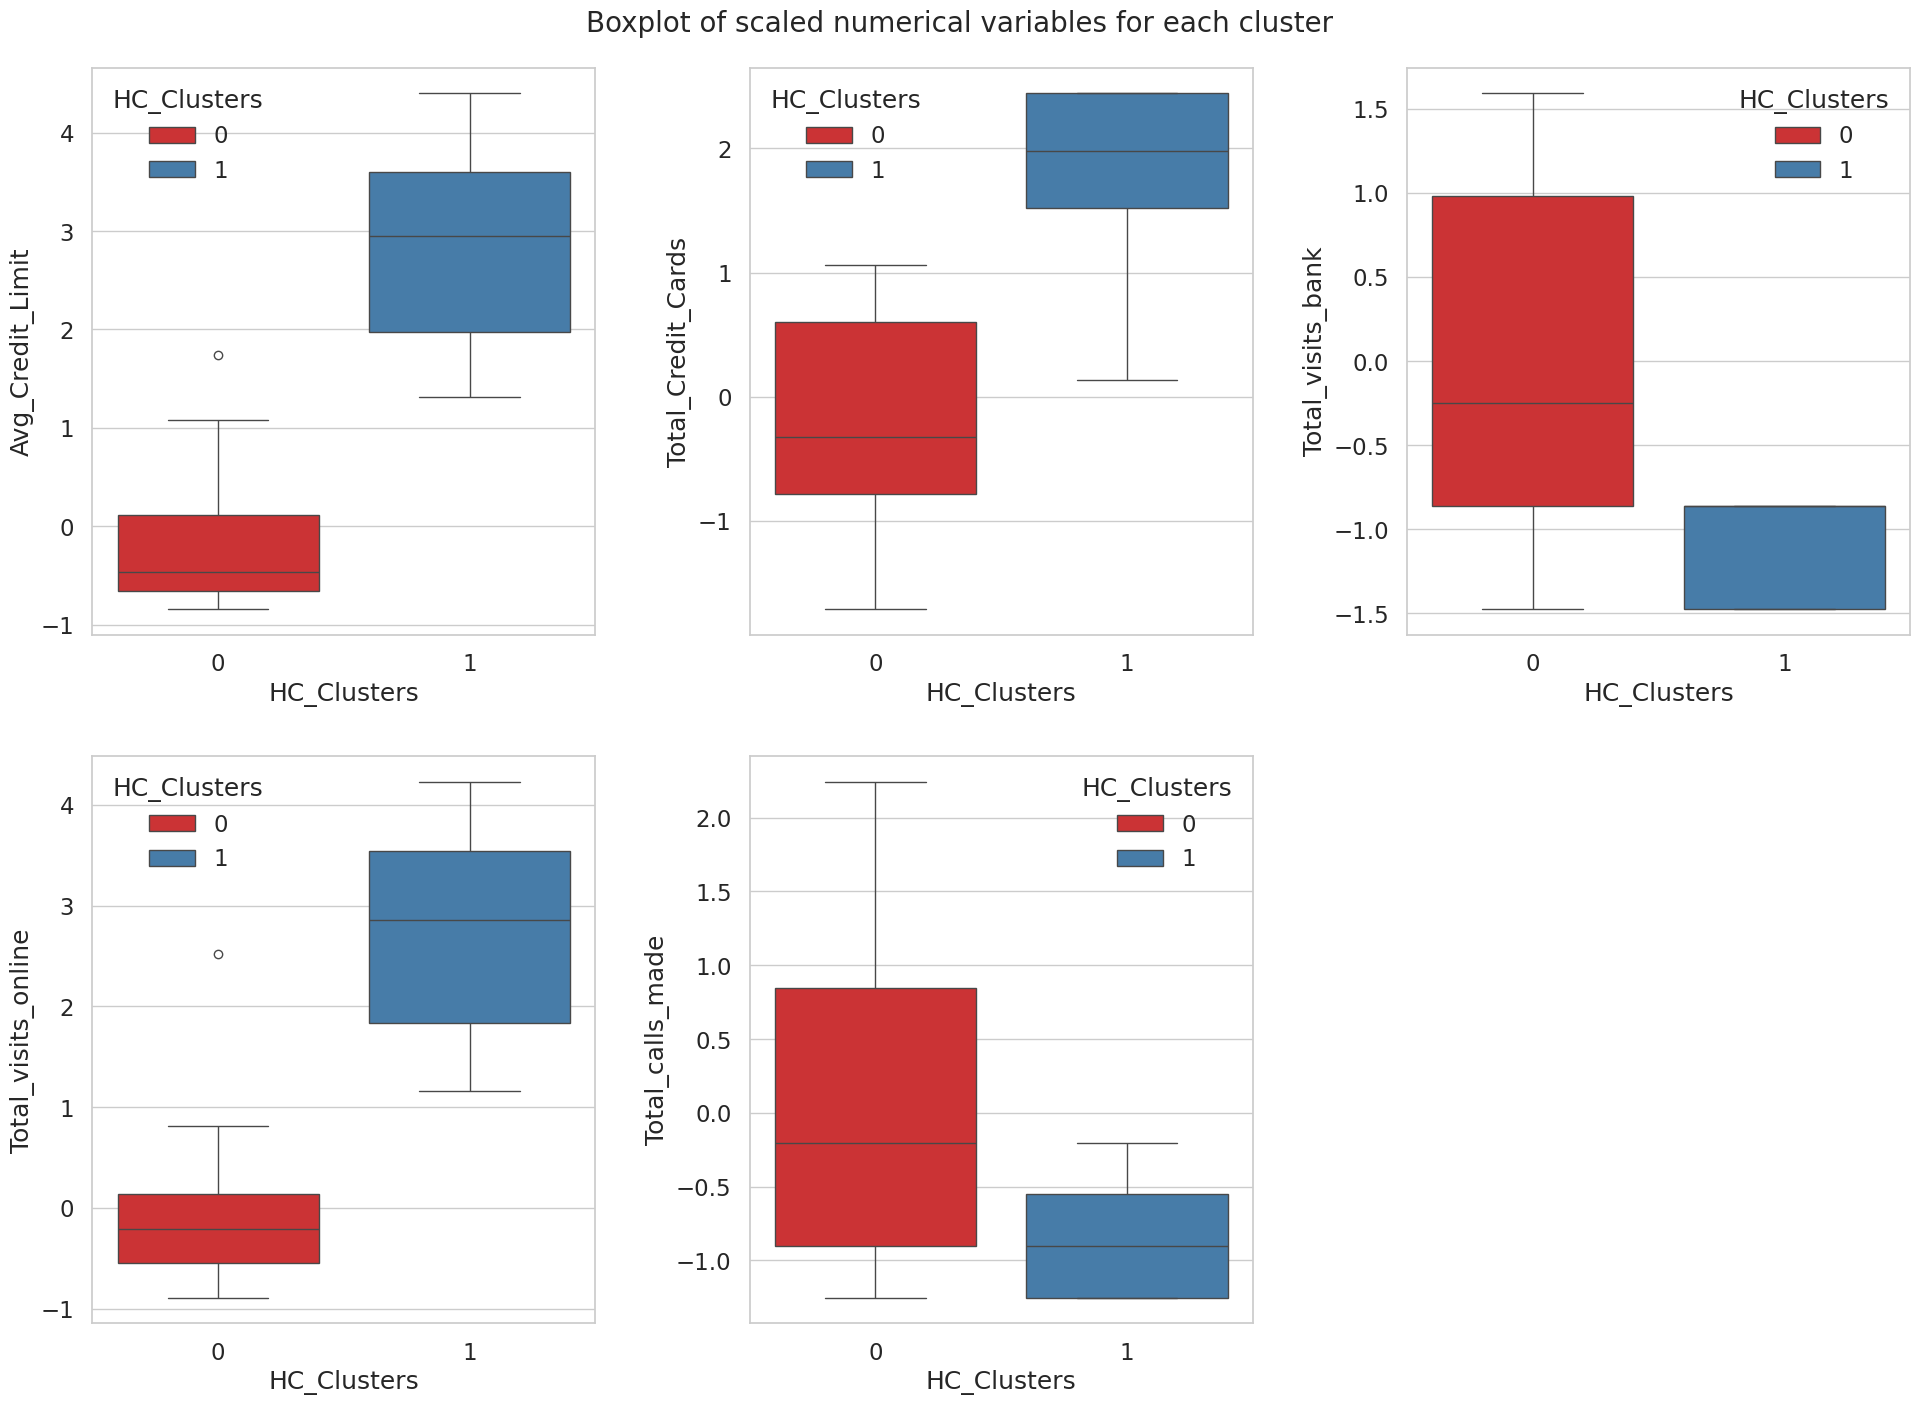

In [ ]:
# plotting boxplot of scaled numerical variables for each cluster
plt.figure(figsize=(20, 35))
plt.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)

for i, variable in enumerate(numerical_col):
  plt.subplot(5, 3, i+1)
  sns.boxplot(
      data=df_scaled.assign(HC_Clusters=HCmodel.labels_),
      x="HC_Clusters",
      y=variable,
      hue="HC_Clusters",
      palette="Set1"
  )

plt.tight_layout(pad=2.0)

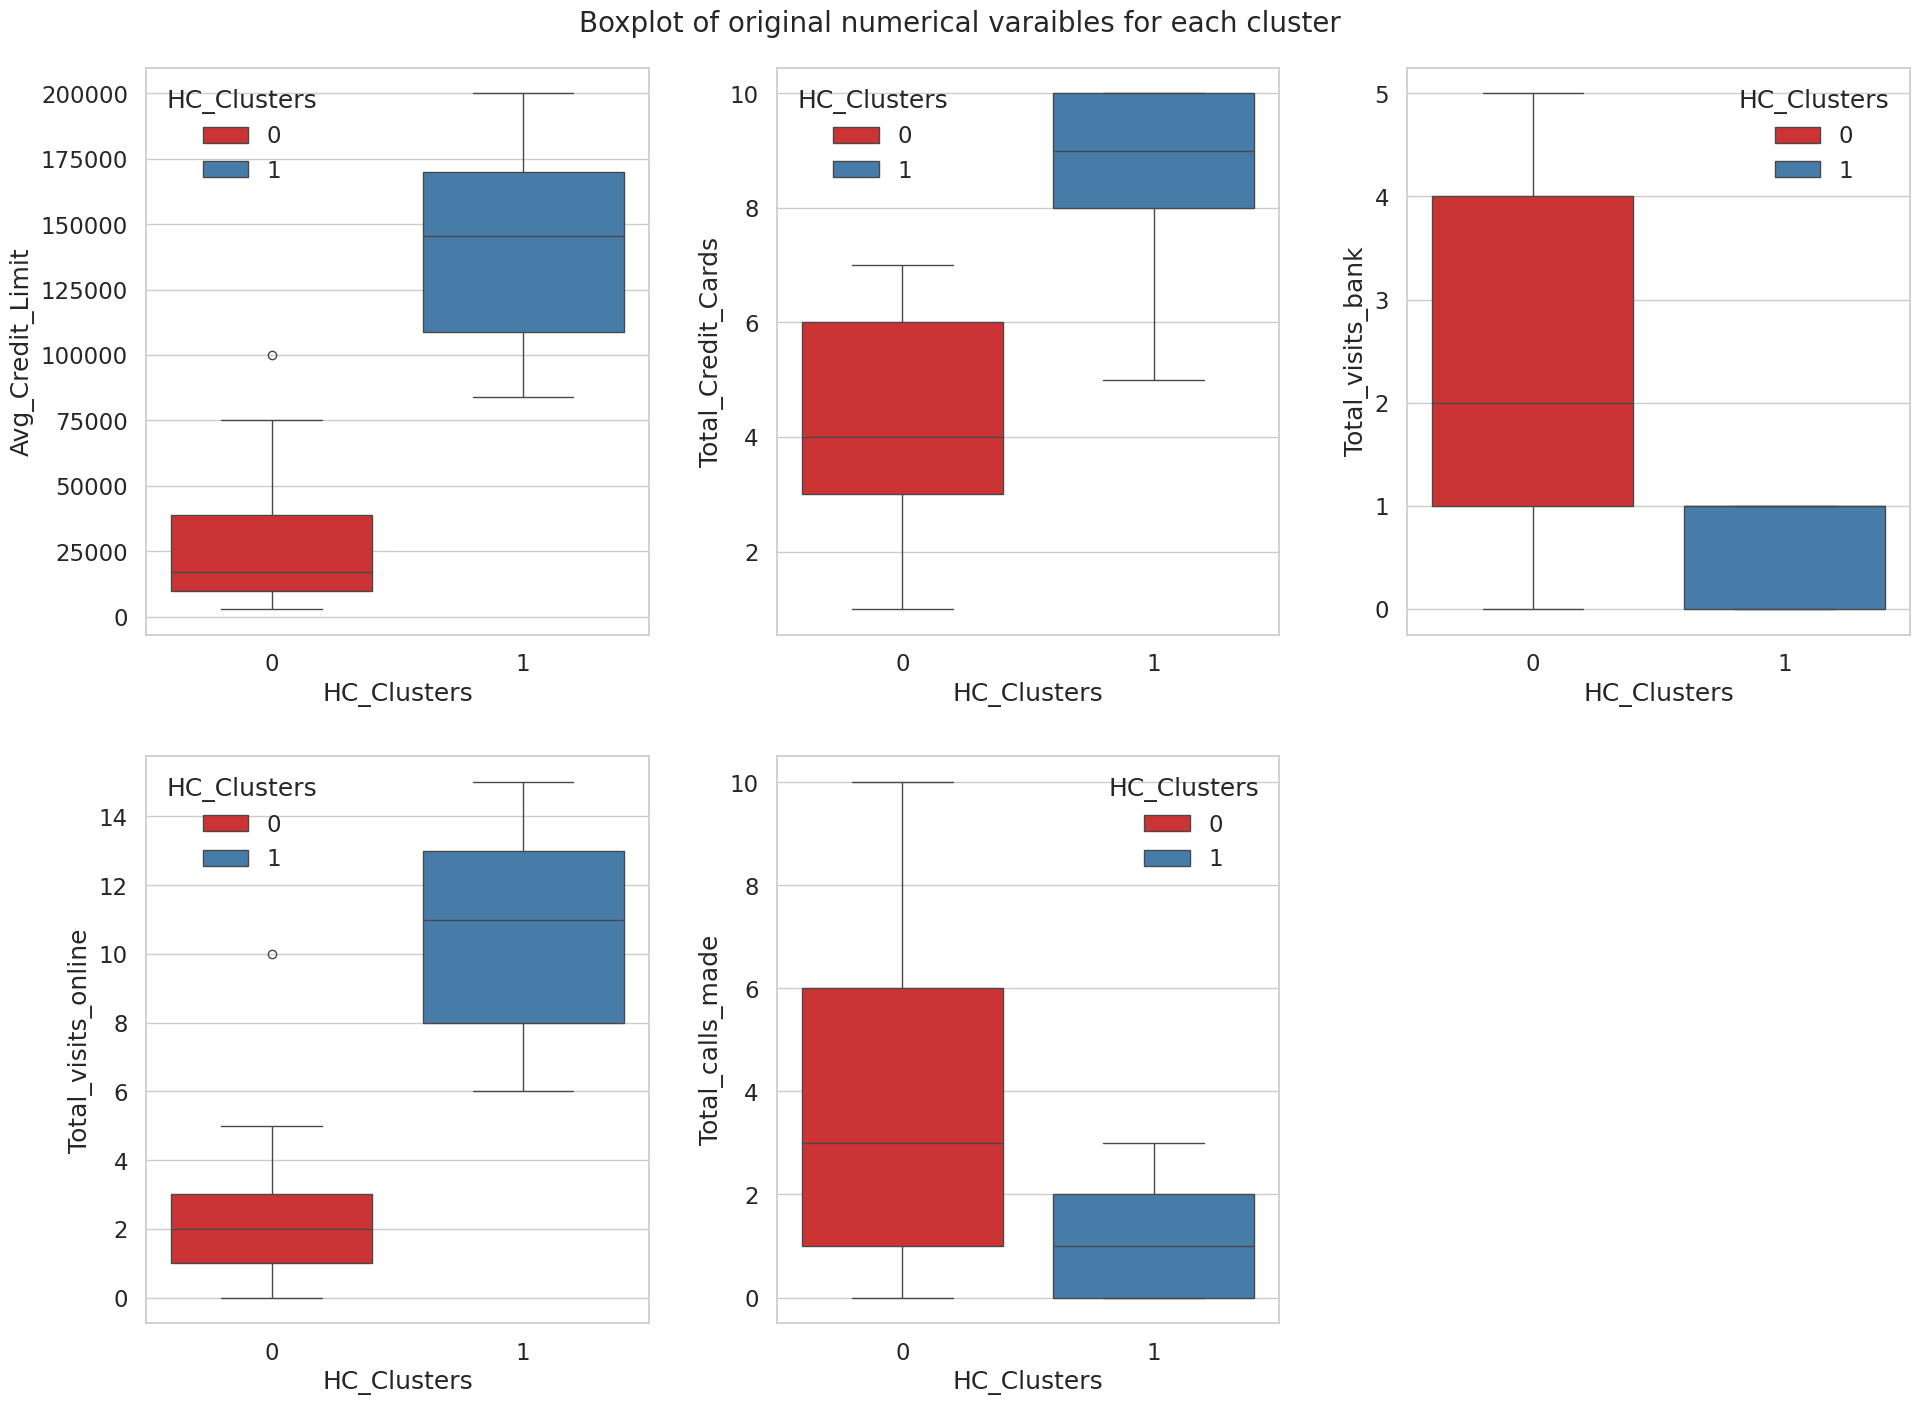

In [ ]:
# plotting boxplot for numerical variables for each cluster
plt.figure(figsize=(20, 35))
plt.suptitle("Boxplot of original numerical varaibles for each cluster", fontsize=20)

for i, variable in enumerate(numerical_col):
  plt.subplot(5, 3, i+1)
  sns.boxplot(data=df, x="HC_Clusters" , y=variable, hue="HC_Clusters", palette="Set1")

plt.tight_layout(pad=2.0)

###Insights

####Cluster 0 :

* Avg_Credit_Limit: ₹25,847 → significantly lower than Cluster 1.

* Total_Credit_Cards: 4.38 cards → moderate usage of credit products.

* Total_visits_bank: 2.55 → prefers offline or in-person interactions.

* Total_visits_online: 1.93 → low online engagement.

* Total_calls_made: 3.79 → relatively high phone interaction.

* Count: 610 customers → this is the dominant segment by volume.

* Profile Summary: Mass-affluent traditional segment – lower credit limit, more bank visits and calls, low online usage. Likely older or less digitally inclined users. These are traditional customers that add less value and need more in person banking to gain their trust.



####Cluster 1 :
- Avg_Credit_Limit: ₹1,41,040 → very high credit limit.

- Total_Credit_Cards: 8.74 → owns many credit cards, highly credit-savvy.

- Total_visits_bank: 0.6 → rarely visits branches.

- Total_visits_online: 10.9 → heavy digital user.

- Total_calls_made: 1.08 → low reliance on phone support.

- Count: 50 customers → a small but elite group.

- Profile Summary:
Digitally savvy premium segment – high credit exposure, highly engaged online, minimal branch/call use. Likely affluent, younger, and tech-forward customers. This is the premium segment that any bank should handle with care. They must be given more premium digital offerings, loyalty programs, or concierge services, promotions, technical upgrades and solutions to retain them and attract more business with technology and least human intervention.

**Now we will check k=3 to understand if it gives better business sense and also to compare with the 3 clusters we received from k-means clustering.**

In [ ]:
df_scaled

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739
...,...,...,...,...,...
655,1.713589,2.443892,-0.860451,2.520519,-1.251537
656,1.314621,2.443892,-0.860451,3.543188,-0.553005
657,2.937092,1.520613,-0.860451,2.179629,-0.902271
658,3.655235,2.443892,-0.860451,4.224968,-1.251537


##Creating Model using sklearn (k=3)

In [ ]:
%%time

HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
HCmodel.fit(df_scaled)

CPU times: user 43.8 ms, sys: 0 ns, total: 43.8 ms
Wall time: 48.1 ms


AgglomerativeClustering(linkage='average', n_clusters=3)

In [ ]:
df["HC_Clusters"] = HCmodel.labels_

In [ ]:
df_scaled

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537
1,0.410293,-0.787585,-1.473731,2.520519,1.891859
2,0.410293,1.058973,-0.860451,0.134290,0.145528
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528
4,1.740187,0.597334,-1.473731,3.202298,-0.203739
...,...,...,...,...,...
655,1.713589,2.443892,-0.860451,2.520519,-1.251537
656,1.314621,2.443892,-0.860451,3.543188,-0.553005
657,2.937092,1.520613,-0.860451,2.179629,-0.902271
658,3.655235,2.443892,-0.860451,4.224968,-1.251537


In [ ]:
df

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,HC_Clusters
0,1,87073,100000,2,1,1,0,0
1,2,38414,50000,3,0,10,9,2
2,3,17341,50000,7,1,3,4,0
3,4,40496,30000,5,1,1,4,0
4,5,47437,100000,6,0,12,3,1
...,...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0,1
656,657,60732,84000,10,1,13,2,1
657,658,53834,145000,8,1,9,1,1
658,659,80655,172000,10,1,15,0,1


##Cluster Profiling

In [ ]:
cluster_profile = df.groupby("HC_Clusters").mean(numeric_only=True)
cluster_profile["count_in_Eeach_segment"] = (
    df.groupby("HC_Clusters").size().values
)
# let's see the details of the customers in each cluster
for cl in df["HC_Clusters"].unique():
  print("In cluster {}, the following customers are present:".format(cl))
  print(df[df["HC_Clusters"] == cl] ["Customer Key"].unique())
  print()

In cluster 0, the following customers are present:
[87073 17341 40496 54838 35254 46635 97825 83125 35483 15129 83290 56486
 31903 45909 14263 46813 81878 35549 85799 39122 81531 69965 18595 44398
 32352 40898 27101 33457 45088 23302 27408 65372 21531 56843 17165 89328
 20072 71402 47496 24808 17036 67193 34423 97109 55382 51811 53936 66504
 53207 18514 51319 36340 36934 95925 49771 22919 21233 74544 52025 45652
 73952 49418 77026 49331 75775 54906 94666 11698 34677 95610 41380 38033
 85337 38994 67911 92956 77641 57565 53814 30712 19785 31384 16374 50878
 78002 83459 91987 51552 72156 24998 45673 11596 87485 28414 81863 33240
 11466 23881 44645 49844 92782 22824 26767 26678 50412 17933 34495 47437
 22610 41159 64672 62483 85614 96548 19137 69028 70779 38244 67046 64897
 46223 36628 17565 77381 11799 81940 66706 87838 94437 33790 44402 29886
 66804 47866 61996 15318 89635 71681 71862 96186 22348 36243 88807 82376
 98126 80347 17649 62807 92522 57459 44579 45476 61994 11398 24702 27824


In [ ]:
# let's display cluster profile
cluster_profile.drop(columns=["Sl_No", "Customer Key"]).style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_Eeach_segment
HC_Clusters,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,387
1,141040.000000,8.740000,0.600000,10.900000,1.080000,50
2,12197.309417,2.403587,0.928251,3.560538,6.883408,223


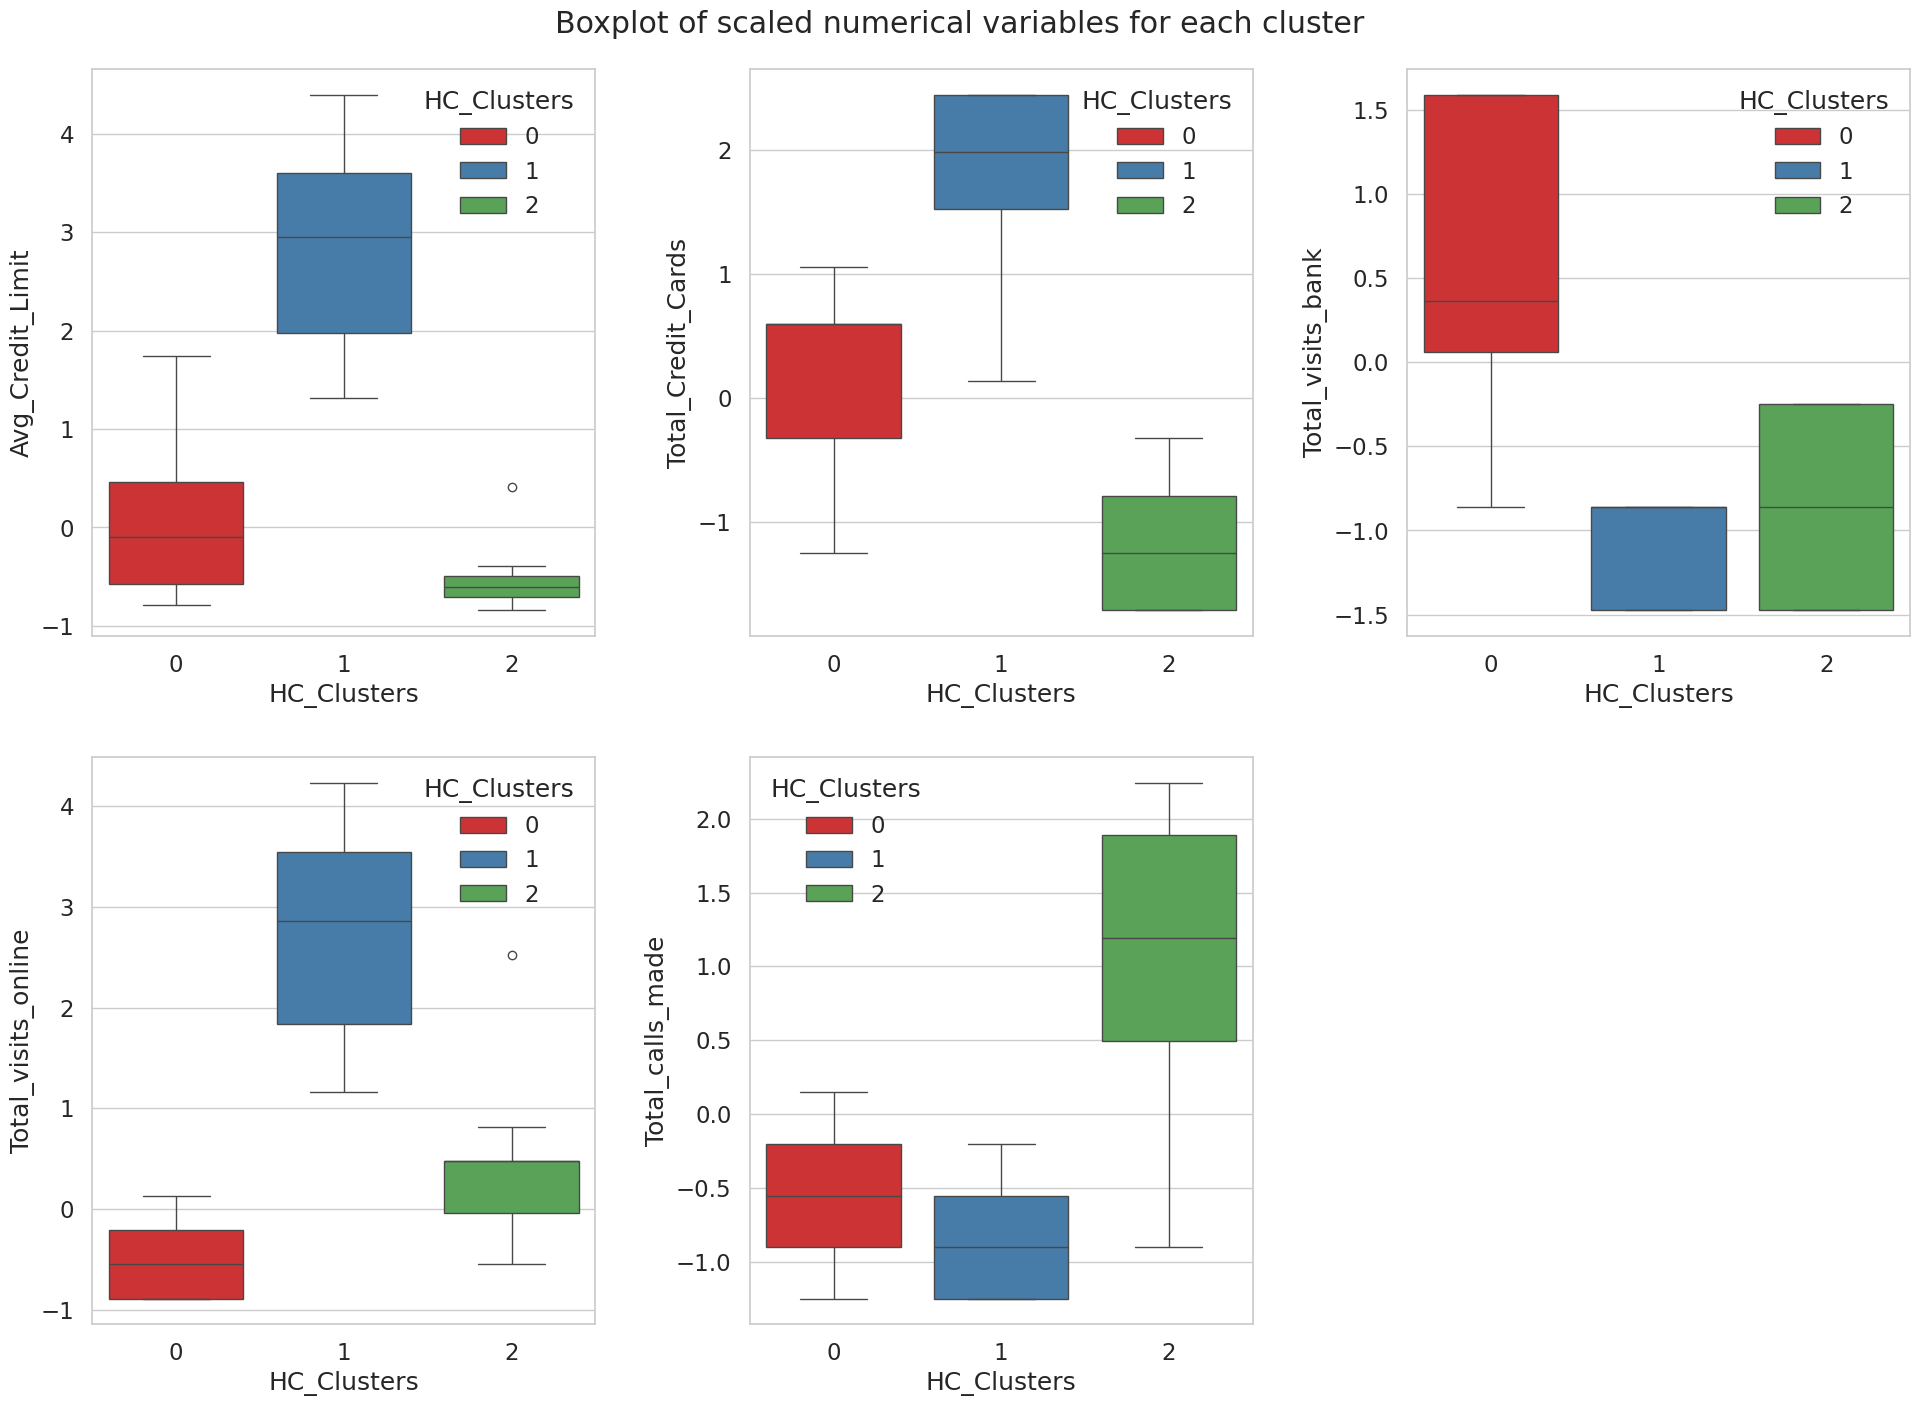

In [ ]:
# plotting boxplot of scaled numerical variables for each cluster
plt.figure(figsize=(20, 35))
plt.suptitle("Boxplot of scaled numerical variables for each cluster")

for i, variable in enumerate(numerical_col):
  plt.subplot(5, 3, i+1)
  sns.boxplot(
      data=df_scaled.assign(HC_Clusters=HCmodel.labels_),
      x="HC_Clusters",
      y=variable,
      hue="HC_Clusters",
      palette="Set1"
  )

plt.tight_layout(pad=2.0)


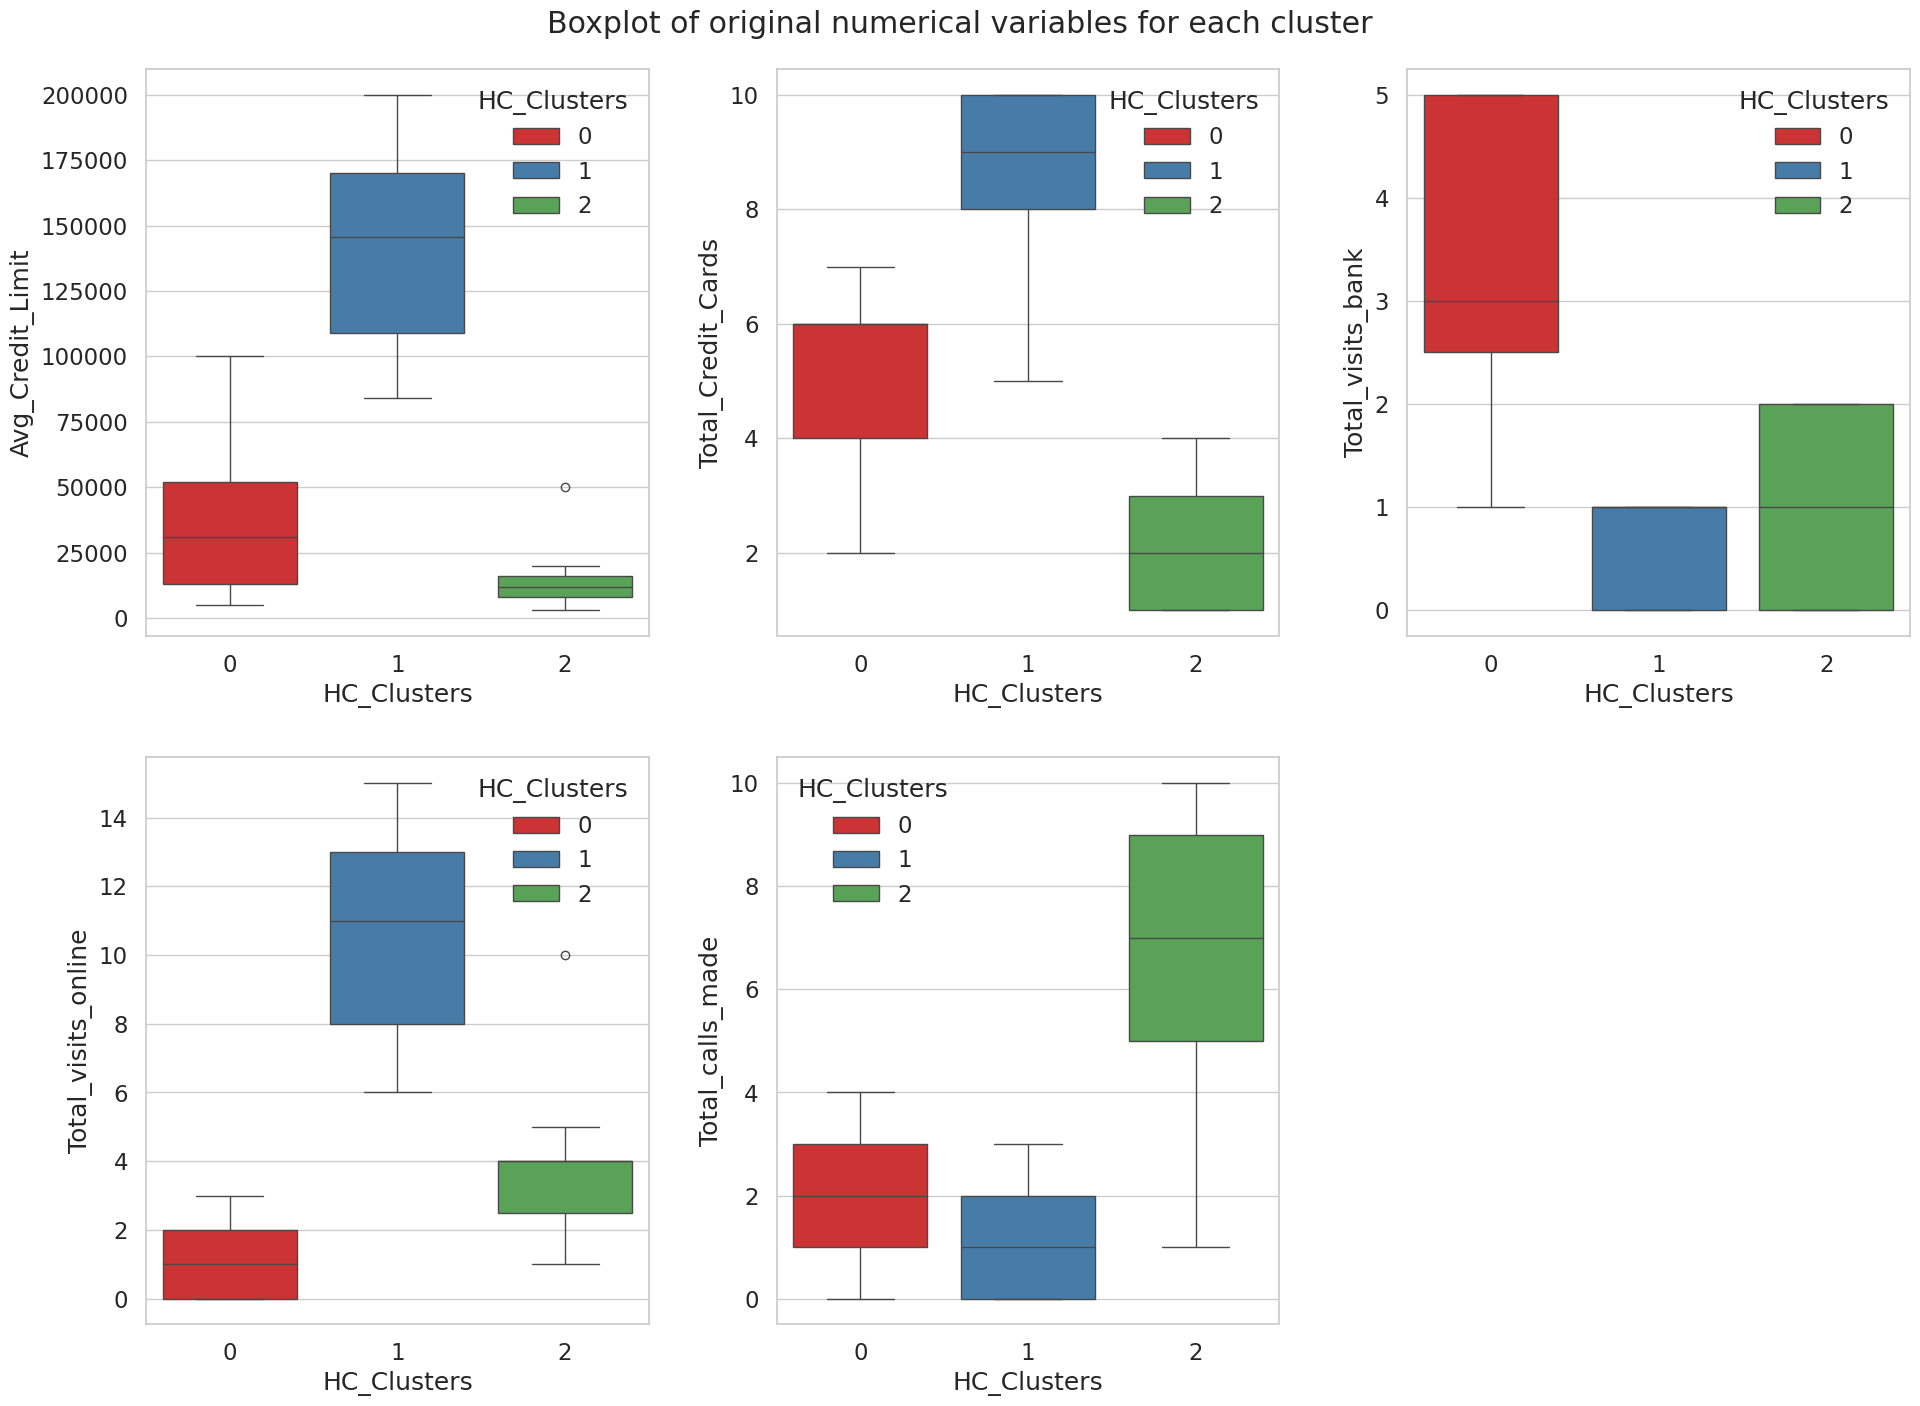

In [ ]:
# plotting boxplot of original numerical variables for each cluster
plt.figure(figsize=(20, 35))
plt.suptitle("Boxplot of original numerical variables for each cluster")

for i, variable in enumerate(numerical_col):
  plt.subplot(5, 3, i+1)
  sns.boxplot(
      data=df, x="HC_Clusters", y=variable, hue="HC_Clusters", palette="Set1"
  )

  plt.tight_layout(pad=2.0)

###Insights


#### Cluster 0: Mass-Affluent Traditional Segment
- Avg_Credit_Limit: ₹33,713 → Moderate credit exposure
- Total_Credit_Cards: ~5.5 → Above-average number of cards
- Total_visits_bank: 3.49 → Highest branch engagement
- Total_visits_online: 0.98 → Very low online usage
- Total_calls_made: ~2 → Moderate use of phone banking
- Size: 387 customers (majority cluster)
- **Insight:**
These customers prefer physical banking (branch) and are less comfortable with digital channels. Likely older, conservative users with decent credit access.
- **Recommendations:** Company should promote assisted digital onboarding, simplify branch-to-digital transitions, offer loyalty rewards for branch visits.

####Cluster 1: Premium Digital Power Users

* Avg_Credit_Limit: ₹1,41,040 → Exceptionally high credit limits
* Total_Credit_Cards: 8.74 → Very high product penetration
* Total_visits_bank: 0.6 → Least likely to visit branches
* Total_visits_online: 10.9 → Extremely high online activity
* Total_calls_made: ~1 → Minimal support needs
* Size: 50 customers (smallest, elite segment)
* **Insight**: These are wealthy, digitally native customers. They prefer self-service channels, may be more urban and younger, and expect seamless digital experiences.
* **Recommendations**: Offer premium digital products, priority servicing, and curated offers. Maintain strong app/UI innovation.

#### Cluster 2: Low-Income, High-Support Segment
- Avg_Credit_Limit: ₹12,197 → Lowest credit limit
- Total_Credit_Cards: 2.4 → Low product ownership
- Total_visits_bank: 0.93 → Low physical interaction
- Total_visits_online: 3.56 → Moderate online usage
- Total_calls_made: 6.88 → Very high support dependency
- Size: 223 customers
- **Insight:**
These customers are financially underserved and rely heavily on phone support, possibly due to issues or low digital proficiency. Likely lower-income, rural or semi-urban customers.
- **Recommendations:** Focus on financial literacy, reduce call center load via proactive communication, offer basic digital banking tools.


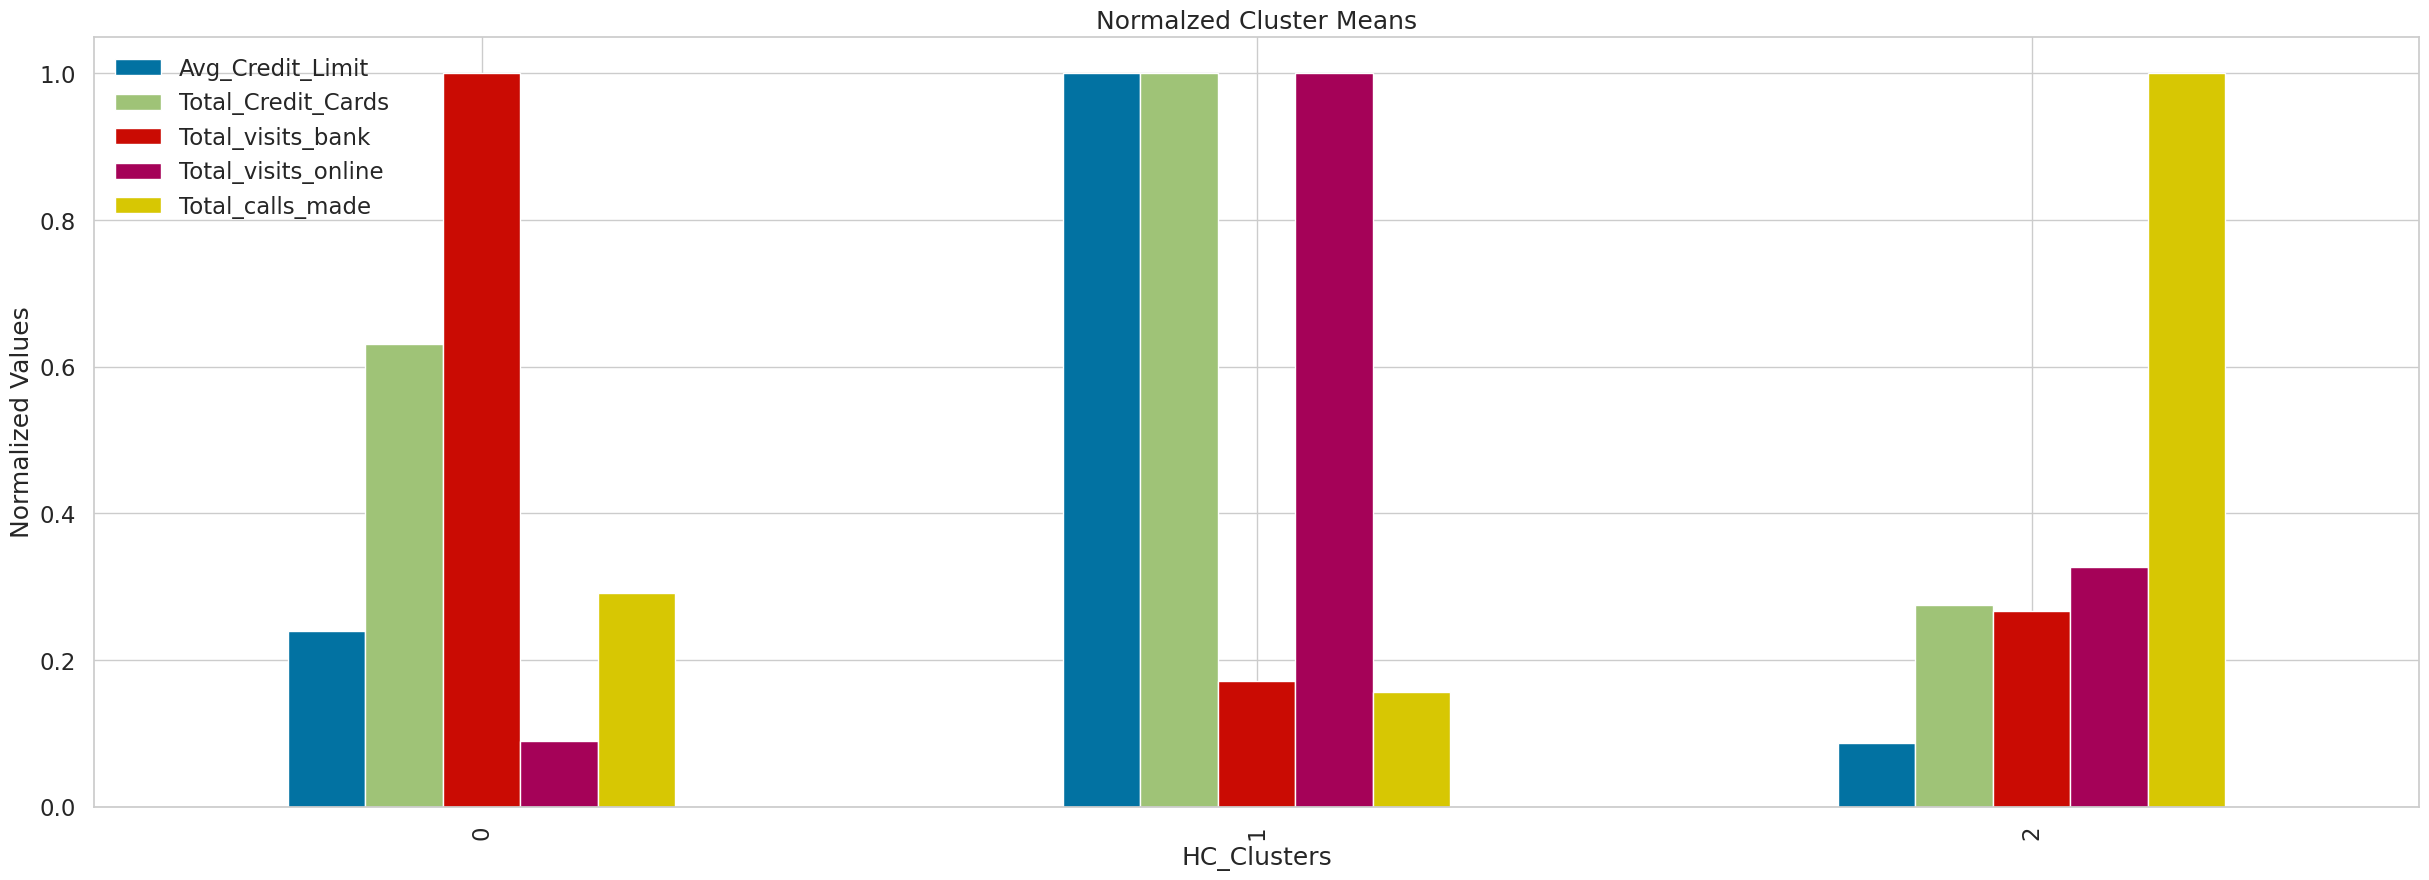

In [ ]:
grouped_data = df.drop(columns=["Sl_No", "Customer Key"]).groupby("HC_Clusters").mean(numeric_only=True)
normalized = grouped_data / grouped_data.max() # scale to [0, 1]

normalized.plot.bar(figsize=(30, 10))
plt.title("Normalzed Cluster Means")
plt.ylabel("Normalized Values")
plt.show()

#K-means (KM) vs Hierarchical Clustering (HC)

A. **From Cluster Profiling, we see that**:
- At k=3, both techniques give clusters of the following types :
1. Mass-Affluent Traditional Segment
2. Premium Digital Power Users
3. Low-Income, High-Support Segment
The count is same for premium segment and at +- 1 for the other 2. Thus , clusters are highly comparable in nature from the 2 techniques

B. **Using Silhouette Scores** is more time-consuming with Dendrograms for HC and gives k=2 for Euclidean Average (Best Cophenetic Correlation of 0.9) HC in contrast to k=3 for K-means Clustering which also makes better business sense

C. At k = 3 clusters, K-means clustering takes more time for execution as compared to that of HC, which is highly efficient, but Dendrogram formation is the most time-consuming as mentioned above

D. Refer business report for detailed comparison of statistics as well as Silhouette scores for each technique. However, At k=3, Silhouette Score for HC = 0.515 (Euclidean Distance Average Linkage) and   Silhouette Score for K-Means Clustering = 0.515. Thus, scores are same at 3 decimal places

E. Adjusted Rand Index (ARI) - Measures Agreement between Clusterings

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(kmeans.labels_, HCmodel.labels_)
print(f"Adjusted Rand Index: {ari:.3f}")

Adjusted Rand Index: 0.994


- The score ranges from -1 to 1:

a. 1.0 = Perfect agreement between two clustering labels.

b. 0.0 = Random labeling (no agreement beyond chance).

c. < 0.0 = Worse than random (very rare).

Our value of 0.994 is very close to 1, so:

**The two clusterings being compared are almost identical.**



F. **Add-on: PCA for Visualization**
Let's use PCA to reduce the data to two dimensions and visualize it to see how well-separated the clusters are for both the Methods used

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(df_scaled)

# storing results in a dataframe
reduced_data_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

# checking the amount of variance explained
print(
    f"The first two principal components explain {np.round(100*pca.explained_variance_ratio_.sum(), 2)}% of the variance in the data."
)

The first two principal components explain 83.16% of the variance in the data.


<Axes: xlabel='Component 1', ylabel='Component 2'>

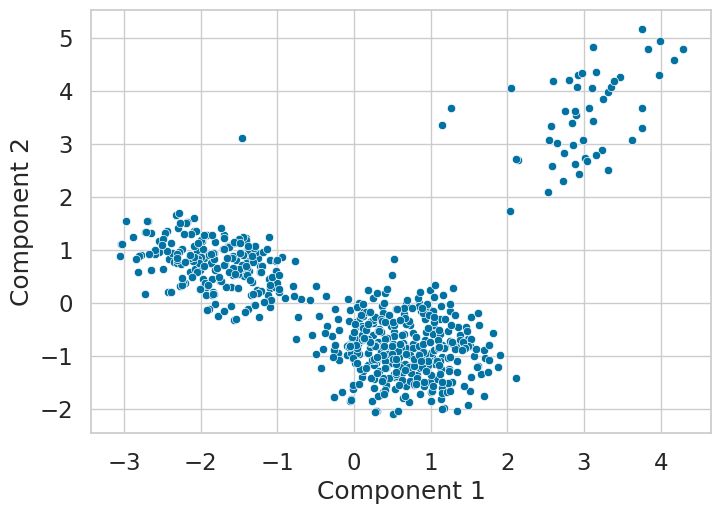

In [ ]:
sns.scatterplot(data=reduced_data_df_pca, x="Component 1", y="Component 2")

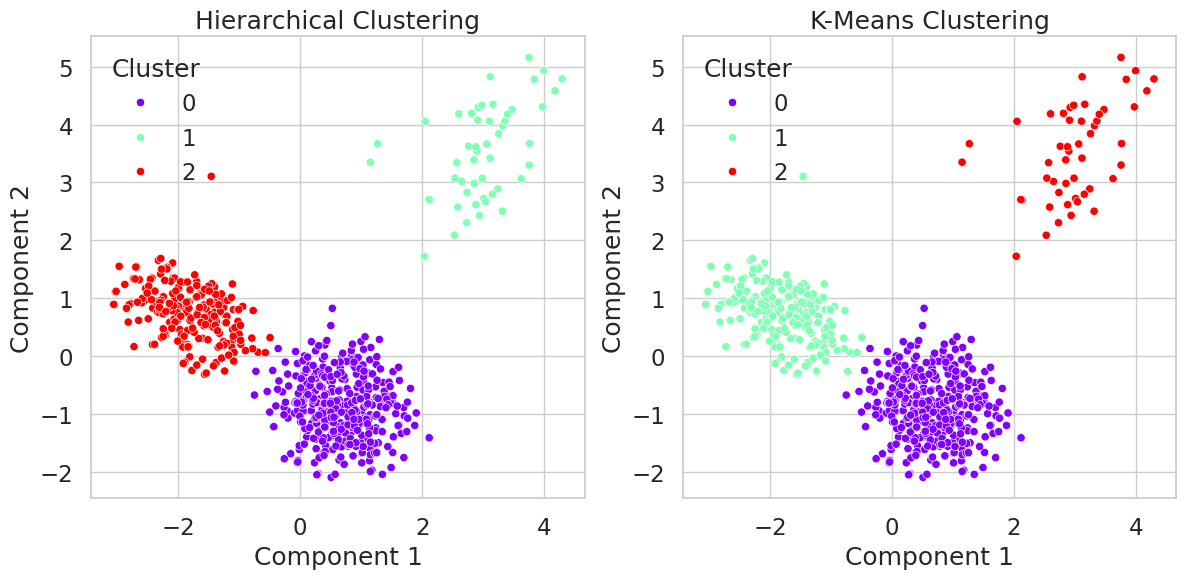

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Hierarchical Clustering
sns.scatterplot(
    data=reduced_data_df_pca,
    x="Component 1",
    y="Component 2",
    hue=HCmodel.labels_,
    palette="rainbow",
    ax=axes[0]
)
axes[0].set_title("Hierarchical Clustering")
axes[0].legend().set_title("Cluster")

# Plot K-Means Clustering
sns.scatterplot(
    data=reduced_data_df_pca,
    x="Component 1",
    y="Component 2",
    hue=kmeans.labels_,
    palette="rainbow",
    ax=axes[1]
)
axes[1].set_title("K-Means Clustering")
axes[1].legend().set_title("Cluster")
#plt.tight_layout()
plt.show()

**It is evident that except one observation being classified differently, rest all observations are classified same by the two techniques**

# Actionable Insights & Recommendations

## Actionable Insights:
-	K-means and Hierarchical Clustering techniques were used to get 3 Discrete Clusters to segment customers based on different banking traits. Clusters formed are 99.4% in agreement with each other with same number of observations in Premium Segment (50) and just 1 observation that has moved from Low-Income, High-Support Segment to Mass-Affluent Traditional Segment in Hierarchical Clustering
-	Silhouette Score of 0.515 and Cophenetic Correlation of 0.9 is obtained implying good quality clusters
-	The segments obtained are as follows:
### Cluster 0: Mass-Affluent Traditional Segment
-	Avg_Credit_Limit: ₹33,713 → Moderate credit exposure
-	Total_Credit_Cards: ~5.5 → Above-average number of cards
-	Total_visits_bank: 3.49 → Highest branch engagement
-	Total_visits_online: 0.98 → Very low online usage
-	Total_calls_made: ~2 → Moderate use of phone banking
-	Size: 387 customers (majority cluster)
-	Insight: These customers prefer physical banking (branch) and are less comfortable with digital channels. Likely older, loyal, conservative users with decent credit access.
-	Recommendations: Company should promote assisted digital onboarding, simplify branch-to-digital transitions, offer loyalty rewards for branch visits.
### Cluster 1: Premium Digital Power Users
-	Avg_Credit_Limit: ₹1,41,040 → Exceptionally high credit limits
-	Total_Credit_Cards: 8.74 → Very high product penetration
-	Total_visits_bank: 0.6 → Least likely to visit branches
-	Total_visits_online: 10.9 → Extremely high online activity
-	Total_calls_made: ~1 → Minimal support needs
-	Size: 50 customers (smallest, elite segment)
-	Insight: These are wealthy, digitally native customers. They prefer self-service channels, may be more urban and younger, and expect seamless digital experiences.
-	Recommendations: Offer premium digital products, priority servicing, and curated offers. Maintain strong app/UI innovation.
### Cluster 2: Low-Income, High-Support Segment
-	Avg_Credit_Limit: ₹12,197 → Lowest credit limit
-	Total_Credit_Cards: 2.4 → Low product ownership
-	Total_visits_bank: 0.93 → Low physical interaction
-	Total_visits_online: 3.56 → Moderate online usage
-	Total_calls_made: 6.88 → Very high support dependency
-	Size: 223 customers
-	Insight: These customers are financially underserved and rely heavily on phone support, possibly due to issues or low digital proficiency. Likely lower-income, rural or semi-urban customers and need more frequent assistance.
-	Recommendations: Focus on financial literacy, reduce call center load via proactive communication, offer basic digital banking tools.


##Business Recommendations:


Company should adopt a segment-specific marketing and service strategy. Combine data-driven insights with operational efficiency to improve customer experience, increase loyalty, and drive revenue across all segments.
### For Cluster 0 (Mass-Affluent Traditional Segment – 59% customer base):
**This is traditional loyal segment and needs to be engaged using cross selling, up selling, etc**
-	Promote assisted digital onboarding at branches.
-	Roll out in-branch loyalty rewards to retain engagement.
-	Use hybrid engagement (branch + digital nudges via SMS/email/app).
-	Segment for cross-sell—especially premium credit cards, wealth management.
### For Cluster 1 (Premium Digital Users – 8% customer base):
 **These are high value premium tech savvy customers and need lucrative retention schemes , otherwise they may move elsewhere for better services**
-	Provide priority service lanes, personal relationship managers, Digital-first promotions and curated offers (e.g., exclusive travel cards).
-	Focus on digital experience excellence—optimize app UI/UX, AI chatbots, instant query resolution.
-	Consider reward partnerships (luxury brands, travel, fintech platforms).
-	Treat them as brand ambassadors—targeted referral schemes and loyalty rewards.
### For Cluster 2 (Low-Income, High-Support – 33% customer base):
 **This is where a lot of untapped potential lies because they are not using a lot of services and have issues. This segment needs improvement to avoid churning out.**
-	Launch financial literacy programs to empower and educate.
-	Offer basic digital training to reduce dependency on phone support.
-	Introduce low-fee digital banking tools, simplified mobile app versions.
-	Proactive customer service to reduce repeat calls and enhance satisfaction.
### Other takeaways :
-	67% of customers had ≤2 online visits/year — suggests low digital penetration. Thus, there is opportunity to boost mobile/online banking adoption across all but Cluster 1.
-	High call volumes in Cluster 2 drives up operational costs. Reducing call dependency via digitization and targeted education can significantly optimize resources. Same with the traditional segment of Cluster 0 that visits bank often.
